### Library imports

In [71]:
from scipy import stats
from itertools import combinations
from scipy.stats import chi2_contingency, f_oneway, kruskal, mannwhitneyu, binomtest
from scipy.stats import tukey_hsd
from matplotlib.ticker import MaxNLocator

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Data preparation and quality checks

- The dataset was loaded into a pandas dataframe for cleaning/preparation
- We changed data types where it made sense (converting sex to numeric)
- We also performed median imputation for missing values
- We looked at the spread of laboratory variables
- We looked at overall distribution of males and females, which informed our later analyses


In [72]:
# First, let's read in the dataset and check out its properties
df = pd.read_csv('HepatitisCdata.csv')
df.head()


,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [73]:
df.shape


(615, 14)

In [74]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  615 non-null    int64  
 1   Category    615 non-null    object 
 2   Age         615 non-null    int64  
 3   Sex         615 non-null    object 
 4   ALB         614 non-null    float64
 5   ALP         597 non-null    float64
 6   ALT         614 non-null    float64
 7   AST         615 non-null    float64
 8   BIL         615 non-null    float64
 9   CHE         615 non-null    float64
 10  CHOL        605 non-null    float64
 11  CREA        615 non-null    float64
 12  GGT         615 non-null    float64
 13  PROT        614 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 67.4+ KB


In [75]:
df['Sex'].unique()


array(['m', 'f'], dtype=object)

In [76]:
# Parse strings to int for sex attribute
df['Sex'] = df['Sex'].map({'m': 1, 'f': 0})
df.head()


,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,1,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,1,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,1,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,1,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,1,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [77]:
df['Category'].unique()


array(['0=Blood Donor', '0s=suspect Blood Donor', '1=Hepatitis',
       '2=Fibrosis', '3=Cirrhosis'], dtype=object)

In [78]:
# Parse strings to int for category attribute
df.rename(columns={'Unnamed: 0': 'id'}, inplace=True)

category = {
    '0=Blood Donor': 0,
    '0s=suspect Blood Donor': 0,
    '1=Hepatitis': 1,
    '2=Fibrosis': 2,
    '3=Cirrhosis': 3
}

df['Category'] = df['Category'].map(category)
df.head()


,id,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0,32,1,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0,32,1,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0,32,1,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0,32,1,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0,32,1,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [79]:
duplicated_ids = df["id"].isna().sum()
assert duplicated_ids == 0, "there are duplicated ids"


In [80]:
# find missing values
df.isna().sum()


id           0
Category     0
Age          0
Sex          0
ALB          1
ALP         18
ALT          1
AST          0
BIL          0
CHE          0
CHOL        10
CREA         0
GGT          0
PROT         1
dtype: int64

In [81]:
# use median interpolation to fill missing values
df['ALB'] = df['ALB'].fillna(df['ALB'].median())
df['ALP'] = df['ALP'].fillna(df['ALP'].median())
df['ALT'] = df['ALT'].fillna(df['ALT'].median())
df['CHOL'] = df['CHOL'].fillna(df['CHOL'].median())
df['PROT'] = df['PROT'].fillna(df['PROT'].median())

df.isna().sum()


id          0
Category    0
Age         0
Sex         0
ALB         0
ALP         0
ALT         0
AST         0
BIL         0
CHE         0
CHOL        0
CREA        0
GGT         0
PROT        0
dtype: int64

In [82]:
df.describe()


,id,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
count,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000,615.000000
mean,308.000000,0.253659,47.408130,0.613008,41.620732,68.222927,28.441951,34.786341,11.396748,8.196634,5.366992,81.287805,39.533171,72.044390
std,177.679487,0.742420,10.055105,0.487458,5.775935,25.646364,25.449889,33.090690,19.673150,2.205657,1.123499,49.756166,54.661071,5.398238
min,1.000000,0.000000,19.000000,0.000000,14.900000,11.300000,0.900000,10.600000,0.800000,1.420000,1.430000,8.000000,4.500000,44.800000
25%,154.500000,0.000000,39.000000,0.000000,38.800000,52.950000,16.400000,21.600000,5.300000,6.935000,4.620000,67.000000,15.700000,69.300000
50%,308.000000,0.000000,47.000000,1.000000,41.950000,66.200000,23.000000,25.900000,7.300000,8.260000,5.300000,77.000000,23.300000,72.200000
75%,461.500000,0.000000,54.000000,1.000000,45.200000,79.300000,33.050000,32.900000,11.200000,9.590000,6.055000,88.000000,40.200000,75.400000
max,615.000000,3.000000,77.000000,1.000000,82.200000,416.600000,325.300000,324.000000,254.000000,16.410000,9.670000,1079.100000,650.900000,90.000000


In [83]:
df["Category"].value_counts()


Category
0    540
3     30
1     24
2     21
Name: count, dtype: int64

In [84]:
df["Sex"].value_counts()


Sex
1    377
0    238
Name: count, dtype: int64

### Exploratory data analysis and initial visualizations

- We created box-and-whisker plots to visualize the spread and distribution of age and the laboratory variables
- We created a correlation heatmap to identify relationships between variables
  - This will guide our later analyses and hypothesis tests as it gives us some variables of interest


In [85]:
# Initializing theme for plots
sns.set_theme(style="whitegrid", context="notebook")

# Colors for box and outliers
# https://matplotlib.org/stable/users/explain/colors/colors.html
BOX_COLOR = "#1f77b4"
OUTLIER_COLOR = "#d62728"


In [86]:
def make_box_and_whiskers(
    ax,
    series,
    title,
    xlabel,
    label_outliers,
):
    sns.boxplot(
        x=series,
        ax=ax,
        color=BOX_COLOR,
        flierprops={
            "marker": "o",
            "markerfacecolor": OUTLIER_COLOR,
            "markeredgecolor": OUTLIER_COLOR,
            "markersize": 4,
        },
    )

    mean = series.mean()
    median = series.median()
    std = series.std()
    summary = f"Mean: {mean:.2f}, Median: {median:.2f}, Std: {std:.2f}"
    ax.text(1, 1.2, summary, transform=ax.transAxes, ha="right", va="center")

    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    if label_outliers:
        outliers = series[(series < lower) | (series > upper)]
        for val in outliers:
            ax.annotate(
                val,
                xy=(val, 0),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8,
                color=OUTLIER_COLOR,
            )

    ax.set_title(title)
    ax.set_xlabel(xlabel)


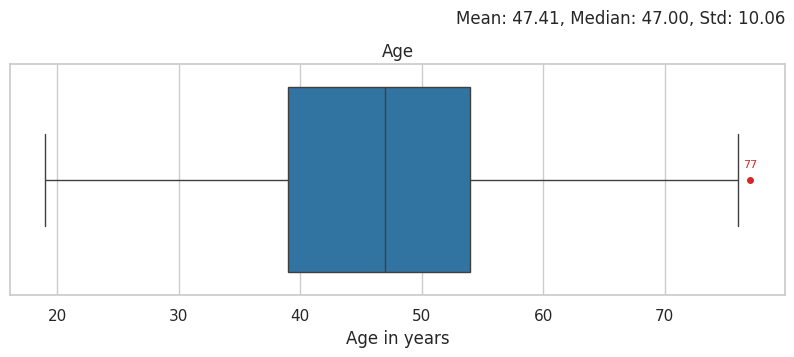

In [87]:
fig, ax = plt.subplots(figsize=(10, 3))
make_box_and_whiskers(ax, df["Age"], "Age", "Age in years", True)
plt.show()


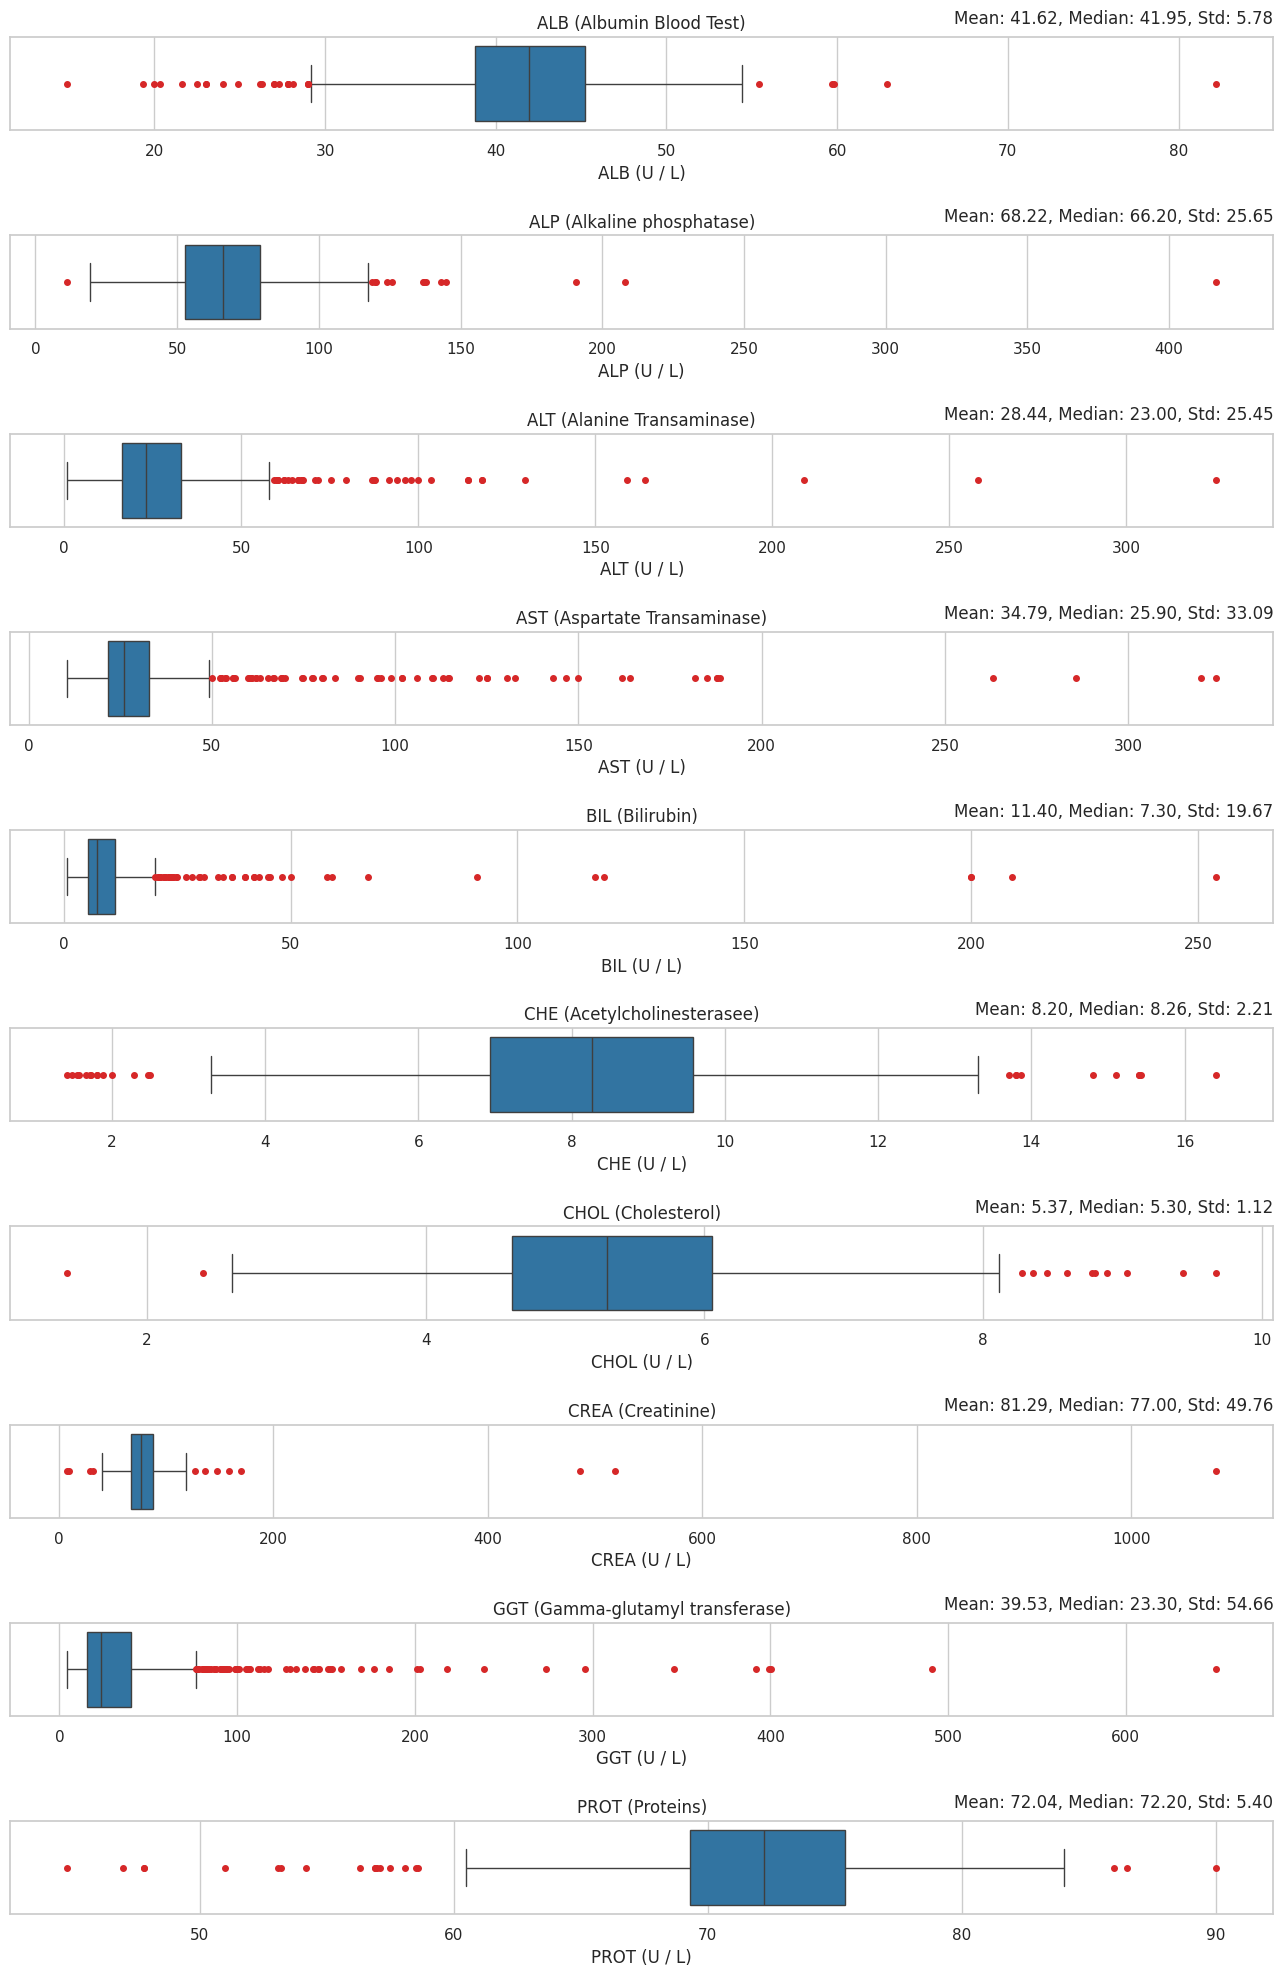

In [88]:
# Laboratory box-and-whisker plots using shared styling
lab_features = ["ALB", "ALP", "ALT", "AST", "BIL", "CHE", "CHOL", "CREA", "GGT", "PROT"]
lab_details = [
    "Albumin Blood Test",
    "Alkaline phosphatase",
    "Alanine Transaminase",
    "Aspartate Transaminase",
    "Bilirubin",
    "Acetylcholinesterasee",
    "Cholesterol",
    "Creatinine",
    "Gamma-glutamyl transferase",
    "Proteins",
]

fig, axes = plt.subplots(len(lab_features), 1, figsize=(13, 2*len(lab_features)))

for i, (col, detail) in enumerate(zip(lab_features, lab_details)):
    make_box_and_whiskers(axes[i], df[col], f"{col} ({detail})", col + " (U / L)", False)

plt.tight_layout()
plt.show()


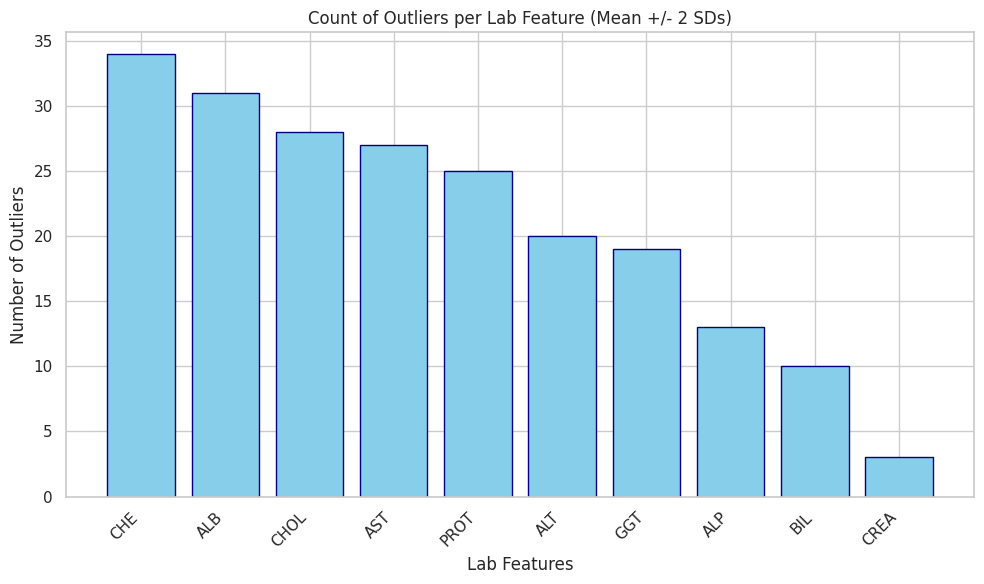

In [89]:
# Next, let's look at the count of outliers per lab column (mean +/- 2 standard deviations)
outliers_by_lab_col = {}

for col in lab_features:
    mean = df[col].mean()
    std = df[col].std()
    lower = mean - 2 * std
    upper = mean + 2 * std
    outliers_by_lab_col[col] = df[(df[col] < lower) | (df[col] > upper)].shape[0]

# plotting the outliers
outliers_df = pd.DataFrame(outliers_by_lab_col.items(), columns=['Lab Feature', 'Outlier Count'])
outliers_df = outliers_df.sort_values(by='Outlier Count', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(outliers_df['Lab Feature'], outliers_df['Outlier Count'], color='skyblue', edgecolor='navy')

plt.xlabel('Lab Features', fontsize=12)
plt.ylabel('Number of Outliers', fontsize=12)
plt.title('Count of Outliers per Lab Feature (Mean +/- 2 SDs)', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


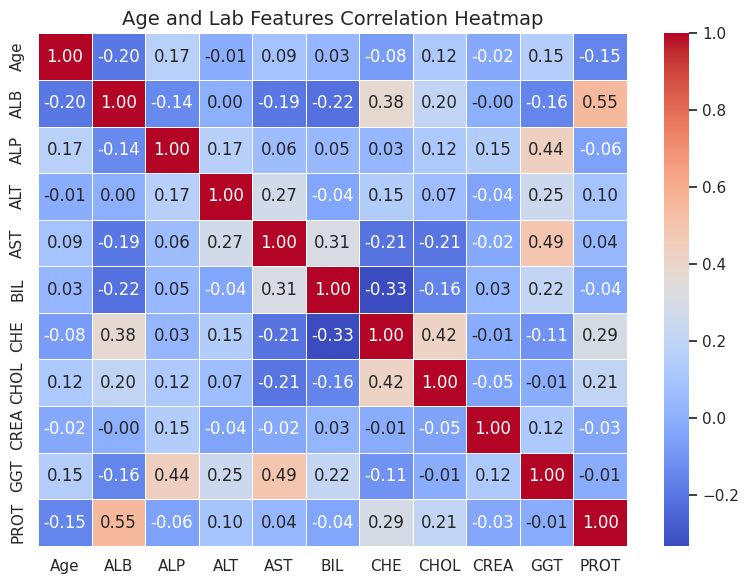

In [90]:
# Correlation matrix for laboratory fields only
cols = ["Age"] + lab_features
corr_matrix = df[cols].corr()

# Create heatmap for the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Age and Lab Features Correlation Heatmap', fontsize=14)
plt.tight_layout()

plt.show()


#### Correlation heat map notes
- The 2 most strongly positive correlated variables are:
  - ALB and PROT (0.55)
  - GGT and AST (0.49)
- The 2 most strongly negatively correlated variables are:
  - BIL and CHE (-0.33)
  - BIL and ALB (-0.22)
- Of note: CREA and age have weak to no correlation with other variables
  - CREA is creatinine, a metabolite commonly used to test kidney function, not liver function
  - Age is likely not a good predictor of liver disease, since it is not related to the laboratory features

## Hypothesis Testing

In [91]:
# Next, we will set up hypothesis testing for a series of tests to come

category_labels = {0: "Blood Donor", 1: "Hepatitis", 2: "Fibrosis", 3: "Cirrhosis"}
sex_labels = {0: "Female", 1: "Male"}

df_test = df.copy()
df_test["CategoryName"] = df_test["Category"].map(category_labels)
df_test["SexName"] = df_test["Sex"].map(sex_labels)

lab_cols = lab_features[:]
feature_cols = ["Age"] + lab_cols
categories = sorted(df_test["Category"].dropna().unique())


### Chi-square test

- We performed a Chi-square test to determine if there is a statistically significant association between sex and category (of liver disease status)

  - Null Hypothesis (H₀): Sex and category are independent: the distribution of categories does not differ between females and males.
  - Alternative Hypothesis (H₁): Sex and category are not independent: the distribution of categories differs between females and males.
  - alpha = 0.05

In [92]:
# First, perform a Chi-square test
sex_cat_ct = pd.crosstab(df_test["SexName"], df_test["CategoryName"])
chi2, p_chi2, dof, expected = chi2_contingency(sex_cat_ct)

print(sex_cat_ct)
print(f"Chi2={chi2:.4f}, p={p_chi2:.4g}, dof={dof}")


CategoryName  Blood Donor  Cirrhosis  Fibrosis  Hepatitis
SexName                                                  
Female                216         10         8          4
Male                  324         20        13         20
Chi2=5.6635, p=0.1292, dof=3


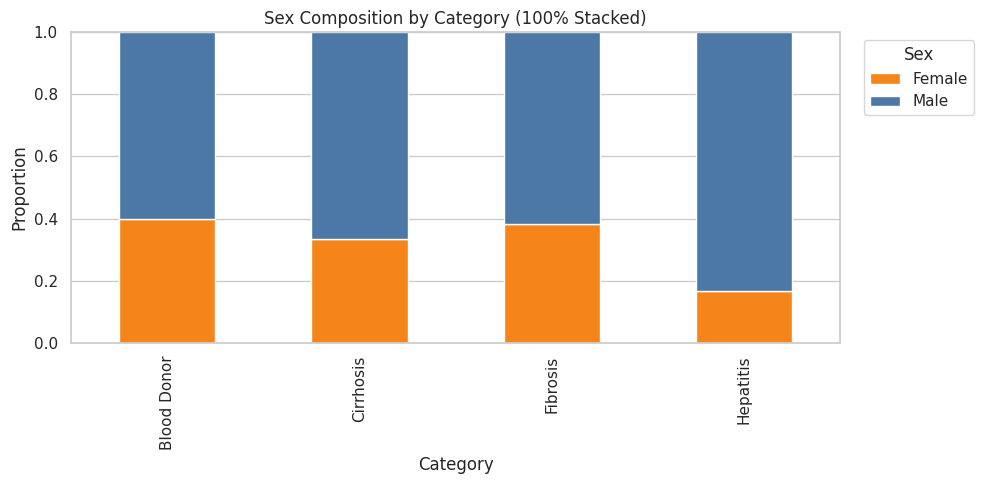

In [93]:
# Visualization for chi-square test: 100% stacked bar chart (Sex proportions within each Category)
sex_cat_prop = sex_cat_ct.div(sex_cat_ct.sum(axis=0), axis=1).T

ax = sex_cat_prop.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    color=["#F58518", "#4C78A8"],
)

ax.set_title("Sex Composition by Category (100% Stacked)")
ax.set_xlabel("Category")
ax.set_ylabel("Proportion")
ax.set_ylim(0, 1)
ax.legend(title="Sex", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


#### Result of Chi-square test

- As p = 0.1292 > 0.05, we fail to reject H₀
- There is insufficient evidence to conclude that sex and disease category are not independent

### Binomial test

- Next, we performed a binomial test in order to determine, for each category, whether the proportion of males in that category significantly differs from the overall proportion in the entire dataset (0.613)
  - Null Hypothesis (H₀): The proportion of males in a given disease category equals the overall male rate in the dataset (p = 0.613).
  - Alternative Hypothesis (H₁): The proportion of males in a given disease category differs from the overall male rate (p ≠ 0.613).
  - alpha = 0.05
- Visualization was done using a stacked bar chart to show overall male/female composition in each category, including the entire dataset

In [94]:
# Perform binomial test

total_male_rate = (df_test["Sex"] == 1).sum() / len(df_test)
results = []
for c in categories:
    sub = df_test[df_test["Category"] == c]
    n = len(sub)
    num_males = (sub["Sex"] == 1).sum()
    num_females = (sub["Sex"] == 0).sum()

    p_binom = binomtest(num_males, n, p=total_male_rate, alternative="two-sided").pvalue
    results.append({
        "Category": category_labels[c],
        "N": n,
        "Male": num_males,
        "Female": num_females,
        "Male_rate": num_males / n,
        "Female_rate": num_females / n,
        "Total_male_rate": total_male_rate,
        "p_binom": p_binom
    })
results_df = pd.DataFrame(results)
display(results_df)


,Category,N,Male,Female,Male_rate,Female_rate,Total_male_rate,p_binom
0,Blood Donor,540,324,216,0.600000,0.400000,0.613008,0.536517
1,Hepatitis,24,20,4,0.833333,0.166667,0.613008,0.034018
2,Fibrosis,21,13,8,0.619048,0.380952,0.613008,1.000000
3,Cirrhosis,30,20,10,0.666667,0.333333,0.613008,0.580853


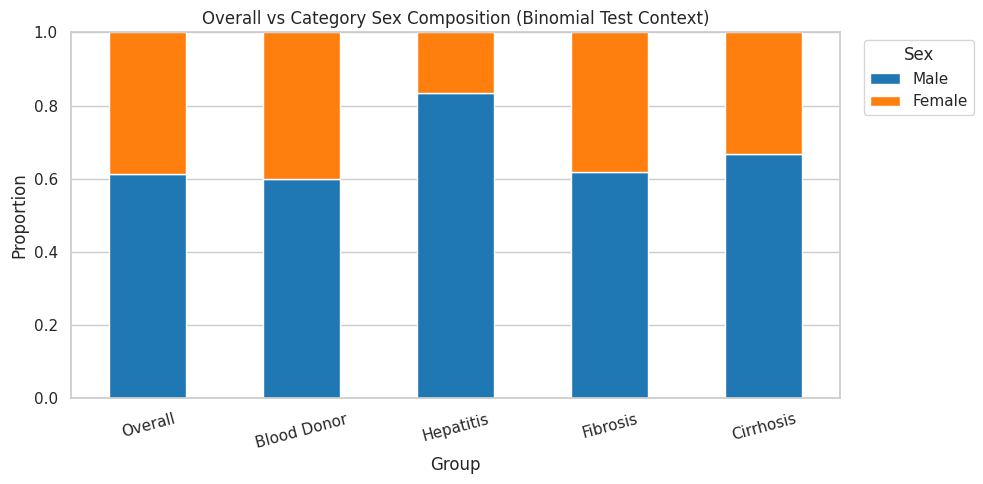

In [95]:
# Visualization for binomial tests: overall male/female composition vs each category
overall_comp = pd.DataFrame({
    "Group": ["Overall"],
    "Male": [total_male_rate],
    "Female": [1 - total_male_rate],
})

category_comp = results_df[["Category", "Male_rate", "Female_rate"]].rename(columns={
    "Category": "Group",
    "Male_rate": "Male",
    "Female_rate": "Female",
})

comp_df = pd.concat([overall_comp, category_comp], ignore_index=True)
comp_df = comp_df.set_index("Group")

ax = comp_df.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    color=["#1f77b4", "#ff7f0e"],
)

ax.set_title("Overall vs Category Sex Composition (Binomial Test Context)")
ax.set_xlabel("Group")
ax.set_ylabel("Proportion")
ax.set_ylim(0, 1)
ax.legend(title="Sex", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


#### Result of Binomial Test

- At the 0.05 significance level, Hepatitis is the only category where we can reject the null hypothesis
  - Males are significantly overrepresentd in the Hepatitis group compared to the overall proportion of males in the dataset
- We fail to reject the null hypothesis in all other categories

### ANOVA and Kruskal-Wallis Tests
- For each numeric laboratory feature, we performed the ANOVA and Kruskal-Wallis tests to determine if that laboratory feature significantly differs across the 4 disease categories
- ANOVA:
  - Null hypothesis (H₀): The mean value of the feature is equal across all categories.
  - Alternative hypothesis (H₁): At least one category has a different mean value for the feature
- Kruskal-Wallis
  - Null hypothesis (H₀): The distribution of the feature is the same across all categories (no difference in central tendency).
  - Alternative hypothesis (H₁): At least one category has a different distribution for the feature.
- alpha = 0.05 for both ANOVA and Kruskal-Wallis
- The distribution of each laboratory feature divided by category was visualized using box plots

In [96]:
# Perform ANOVA and Kruskal-Wallis Tests
result_rows = []
for feat in feature_cols:
    groups = [df_test.loc[df_test["Category"] == cat, feat].dropna().values for cat in categories]
    if all(len(g) > 1 for g in groups):
        f_stat, p_anova = f_oneway(*groups) # decamp the 2d list into separate arguments
        h_stat, p_kruskal = kruskal(*groups)

        result_rows.append({
            "Feature": feat,
            "ANOVA_F": f_stat,
            "ANOVA_p": p_anova,
            "Kruskal_H": h_stat,
            "Kruskal_p": p_kruskal
        })
result_df = pd.DataFrame(result_rows)
display(result_df)


,Feature,ANOVA_F,ANOVA_p,Kruskal_H,Kruskal_p
0,Age,11.940157,1.318064e-07,29.098353,2.135352e-06
1,ALB,28.745777,2.134976e-17,55.998433,4.204172e-12
2,ALP,17.244577,9.254460e-11,46.196793,5.150542e-10
3,ALT,11.771256,1.663988e-07,22.066434,6.318748e-05
4,AST,141.436468,1.362926e-69,155.103774,2.087700e-33
5,BIL,91.165092,9.168611e-49,94.561523,2.293746e-20
6,CHE,53.699560,8.117300e-31,66.587764,2.294400e-14
7,CHOL,19.717587,3.273604e-12,51.589324,3.663758e-11
8,CREA,14.847303,2.427382e-09,9.487463,2.346511e-02
9,GGT,54.365113,3.705367e-31,103.102781,3.343824e-22


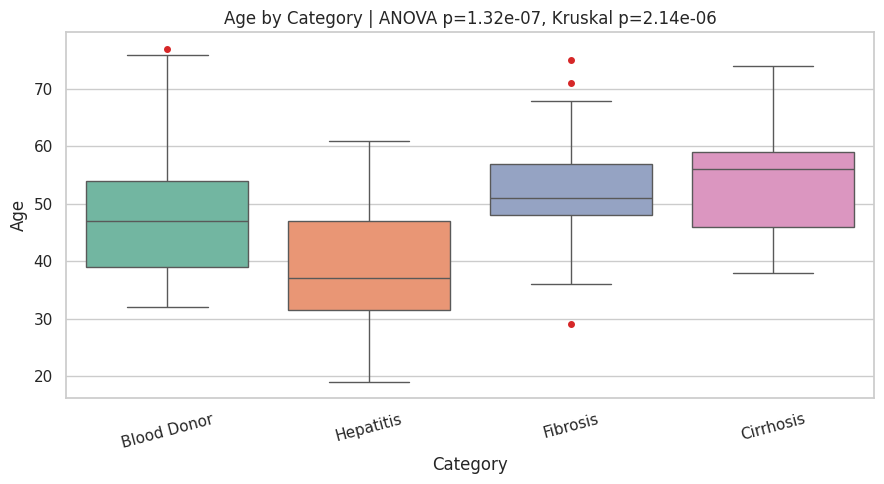

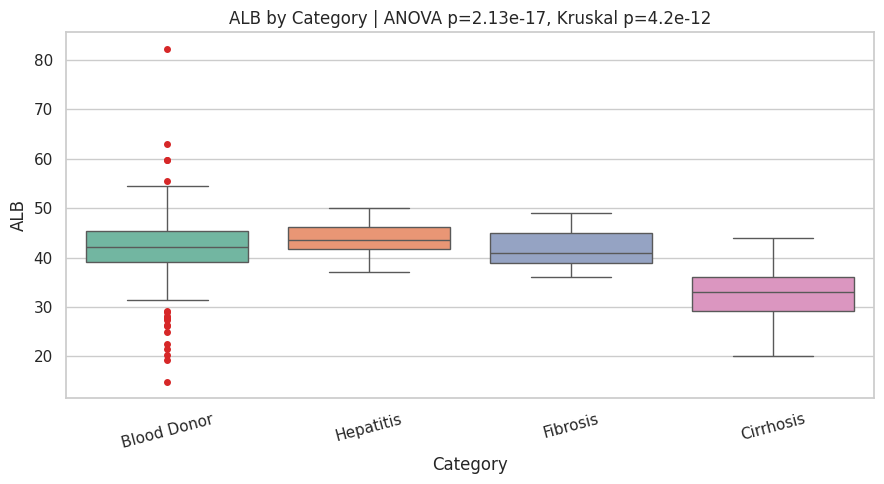

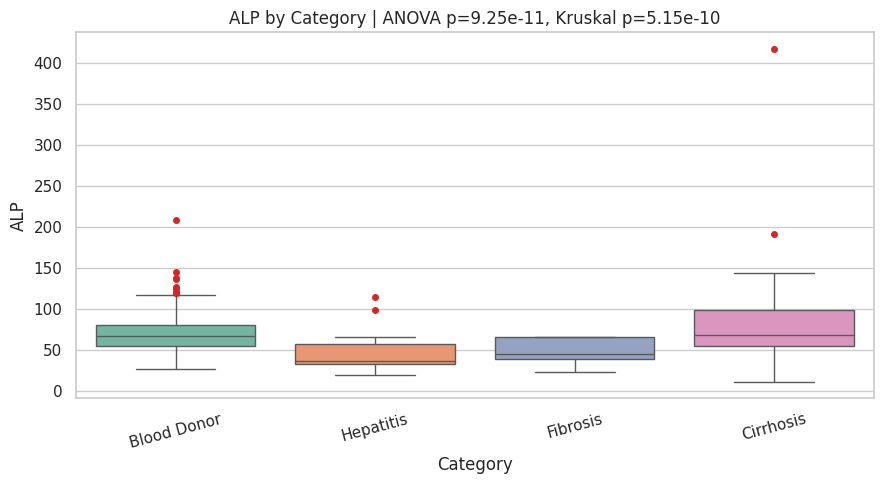

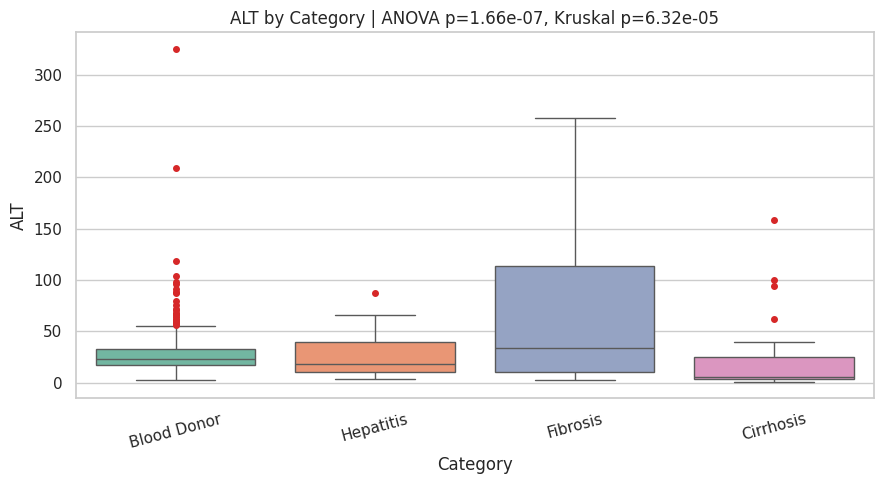

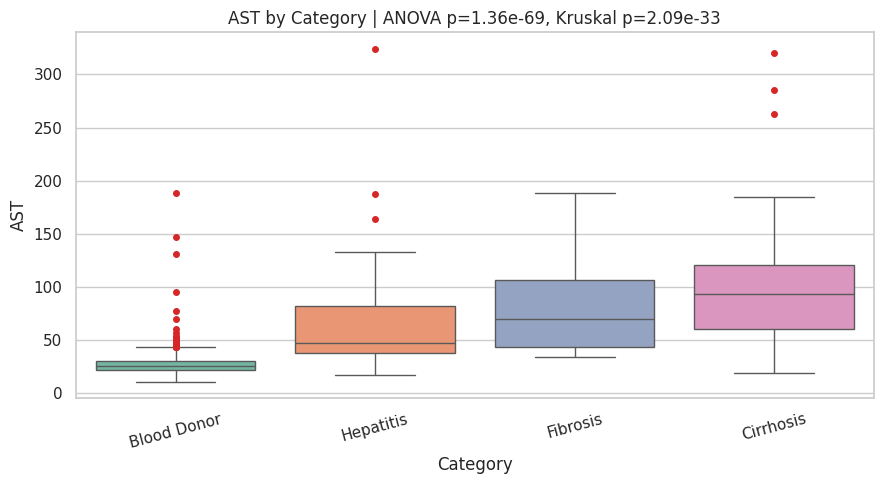

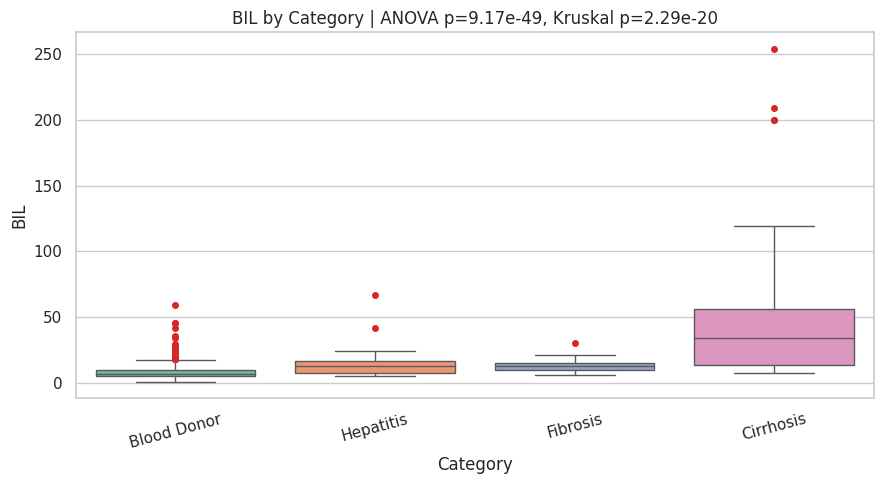

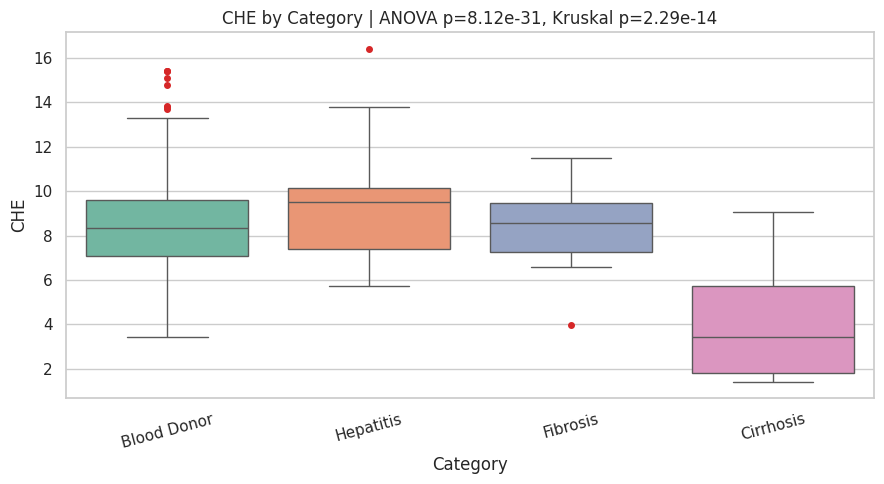

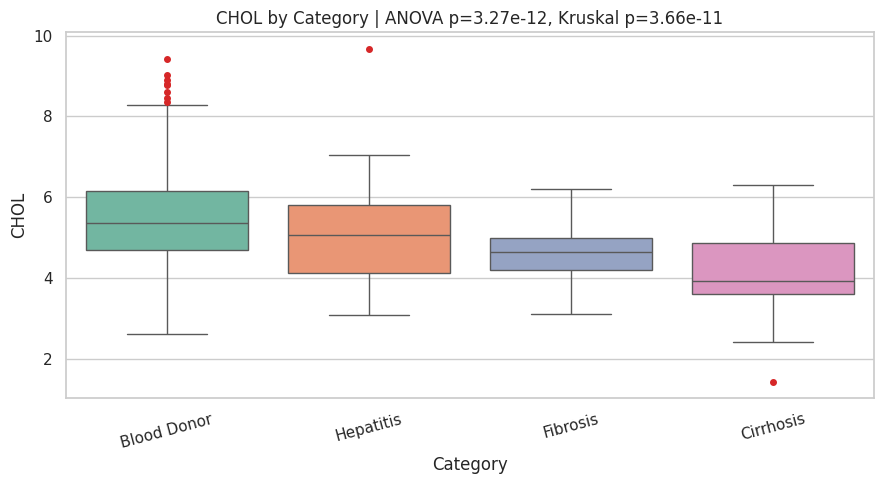

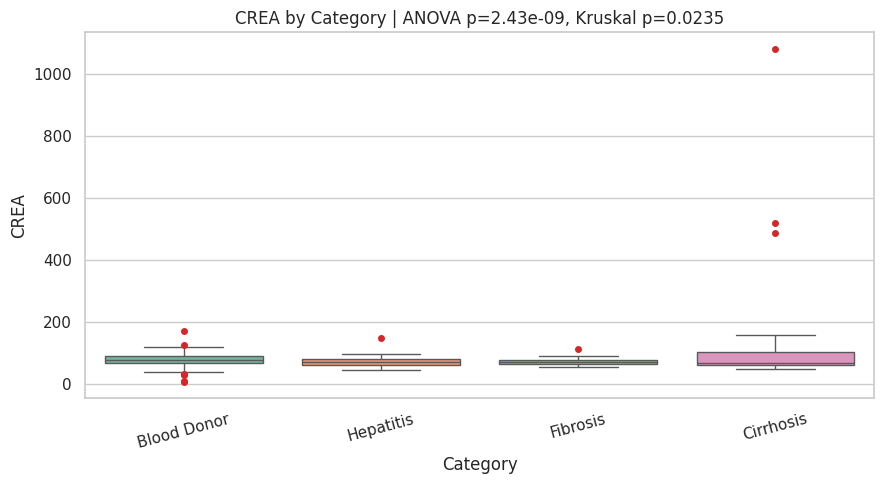

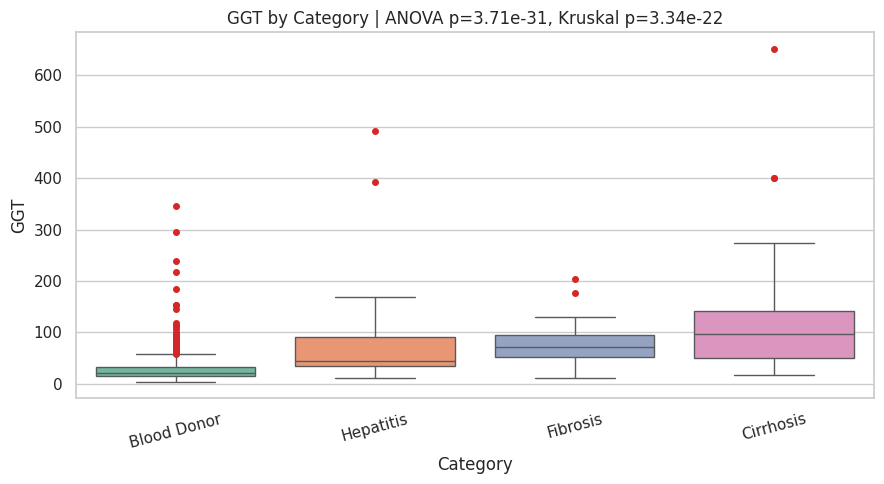

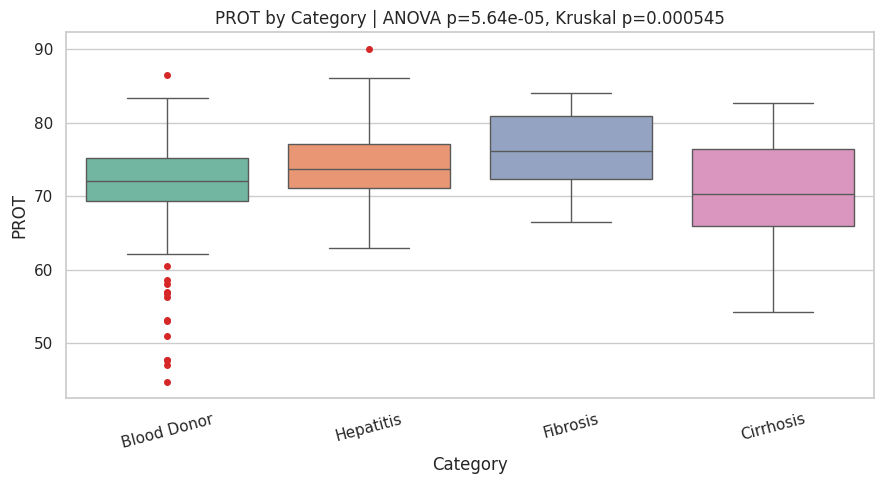

In [97]:
# Visual companion for ANOVA and Kruskal-Wallis: vertical box plots per feature
category_order = [category_labels[c] for c in categories]
category_palette = dict(zip(category_order, sns.color_palette("Set2", n_colors=len(category_order))))

for feat in feature_cols:
    pvals = result_df.loc[result_df["Feature"] == feat, ["ANOVA_p", "Kruskal_p"]]
    if not pvals.empty:
        anova_p = pvals.iloc[0]["ANOVA_p"]
        kruskal_p = pvals.iloc[0]["Kruskal_p"]
        title = f"{feat} by Category | ANOVA p={anova_p:.3g}, Kruskal p={kruskal_p:.3g}"
    else:
        title = f"{feat} by Category"

    fig, ax = plt.subplots(figsize=(9, 5))

    sns.boxplot(
        data=df_test,
        x="CategoryName",
        y=feat,
        hue="CategoryName",
        order=category_order,
        hue_order=category_order,
        palette=category_palette,
        dodge=False,
        flierprops={
            "marker": "o",
            "markerfacecolor": OUTLIER_COLOR,
            "markeredgecolor": OUTLIER_COLOR,
            "markersize": 4,
        },
        ax=ax,
    )

    ax.set_title(title)
    ax.set_xlabel("Category")
    ax.set_ylabel(feat)
    ax.tick_params(axis="x", rotation=15)

    plt.tight_layout()
    plt.show()



#### ANOVA and Kruskal-Wallis test results

- At a 0.05 significance level, there is a significant difference across categories for **all** laboratory features
  - At least one disease group differs from the others for each laboratory feature
- The strongest differences are in AST, BIL, GGT, and CHE, which each have very small p-values from both tests
  - This suggests that these are the most distinguishing lab feature between category

### Post-hoc Tukey HSD
- Given the results of the ANOVA and Kruskal-Willis tests, we can perform a post-hoc Tukey HSD test to determine exactly which category differs for each laboratory feature
  - Null hypothesis (H₀): The mean value of the feature is equal between the two groups being compared (Group 1 = Group 2).
  - Null hypothesis (H₁): The mean value of the feature differs between the two groups being compared (Group 1 ≠ Group 2).
  - alpha = 0.05
- For each significant Tukey comparison, we created a visualization with:
  - a histogram that overlays the distribution of laboratory feature in the differing categories
  - box and whisker plots of the laboratory features side by side

In [98]:
# Perform post hoc Tukey HSD tests

posthoc_rows = []
for feat in feature_cols:
    groups = []
    names = []
    for c in categories:
        vals = df_test.loc[df_test["Category"] == c, feat].dropna().values
        if len(vals) >= 2:
            groups.append(vals)
            names.append(category_labels[c])

    if len(groups) >= 2:
        res = tukey_hsd(*groups)
        for i in range(len(names)):
            for j in range(i + 1, len(names)):
                posthoc_rows.append({
                    "Feature": feat,
                    "Group1": names[i],
                    "Group2": names[j],
                    "Mean_diff": float(res.statistic[i, j]),
                    "p_tukey": float(res.pvalue[i, j])
                })

posthoc_df = pd.DataFrame(posthoc_rows)
display(posthoc_df.sort_values(["Feature", "p_tukey"]))

print("Significant post hoc differences (Tukey p < 0.05):")
display(posthoc_df[posthoc_df["p_tukey"] < 0.05].sort_values(["Feature", "p_tukey"]))


,Feature,Group1,Group2,Mean_diff,p_tukey
8,ALB,Blood Donor,Cirrhosis,9.208704,0.000000e+00
10,ALB,Hepatitis,Cirrhosis,11.035000,1.934897e-12
11,ALB,Fibrosis,Cirrhosis,8.963571,5.946091e-08
6,ALB,Blood Donor,Hepatitis,-1.826296,3.707664e-01
9,ALB,Hepatitis,Fibrosis,2.071429,5.766959e-01
...,...,...,...,...,...
61,PROT,Blood Donor,Fibrosis,-4.224630,2.138737e-03
64,PROT,Hepatitis,Cirrhosis,4.576667,9.410397e-03
60,PROT,Blood Donor,Hepatitis,-2.824630,5.379246e-02
62,PROT,Blood Donor,Cirrhosis,1.752037,2.949026e-01


Significant post hoc differences (Tukey p < 0.05):


,Feature,Group1,Group2,Mean_diff,p_tukey
8,ALB,Blood Donor,Cirrhosis,9.208704,0.000000e+00
10,ALB,Hepatitis,Cirrhosis,11.035000,1.934897e-12
11,ALB,Fibrosis,Cirrhosis,8.963571,5.946091e-08
16,ALP,Hepatitis,Cirrhosis,-42.691667,3.118669e-09
17,ALP,Fibrosis,Cirrhosis,-37.821429,6.186399e-07
12,ALP,Blood Donor,Hepatitis,23.744815,2.891485e-05
14,ALP,Blood Donor,Cirrhosis,-18.946852,2.828571e-04
13,ALP,Blood Donor,Fibrosis,18.874577,3.498362e-03
19,ALT,Blood Donor,Fibrosis,-31.990000,6.441512e-08
23,ALT,Fibrosis,Cirrhosis,36.630000,1.710272e-06


Significant comparisons to plot: 40


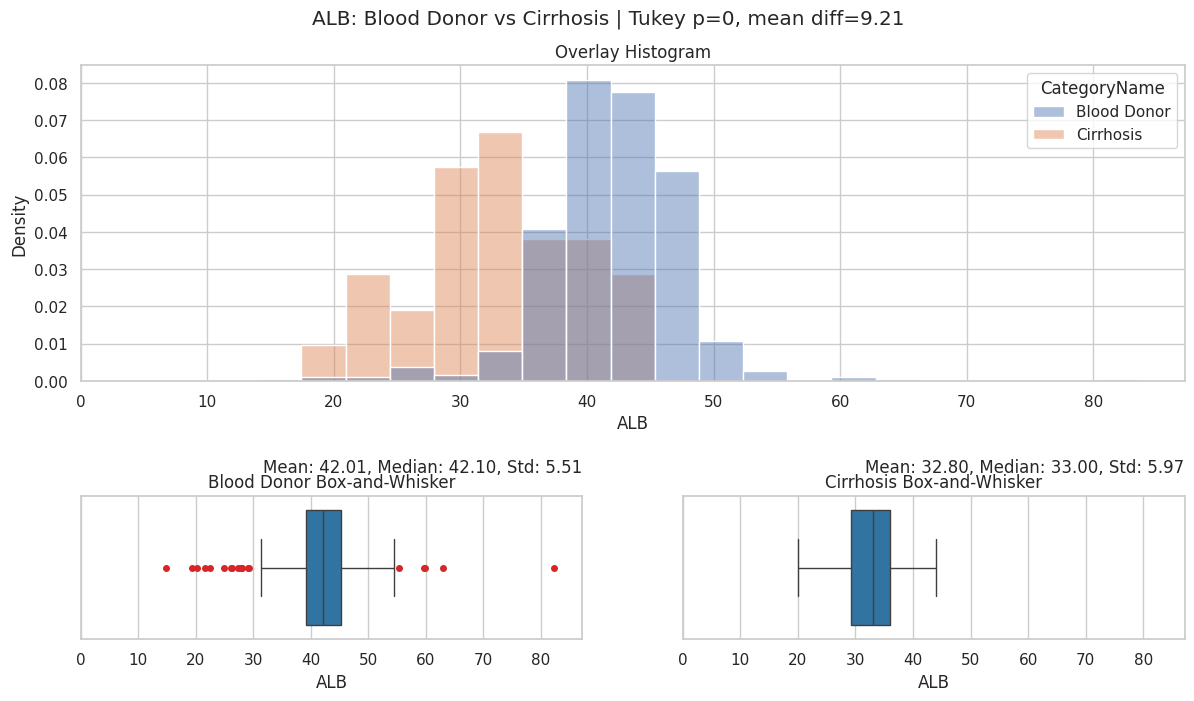

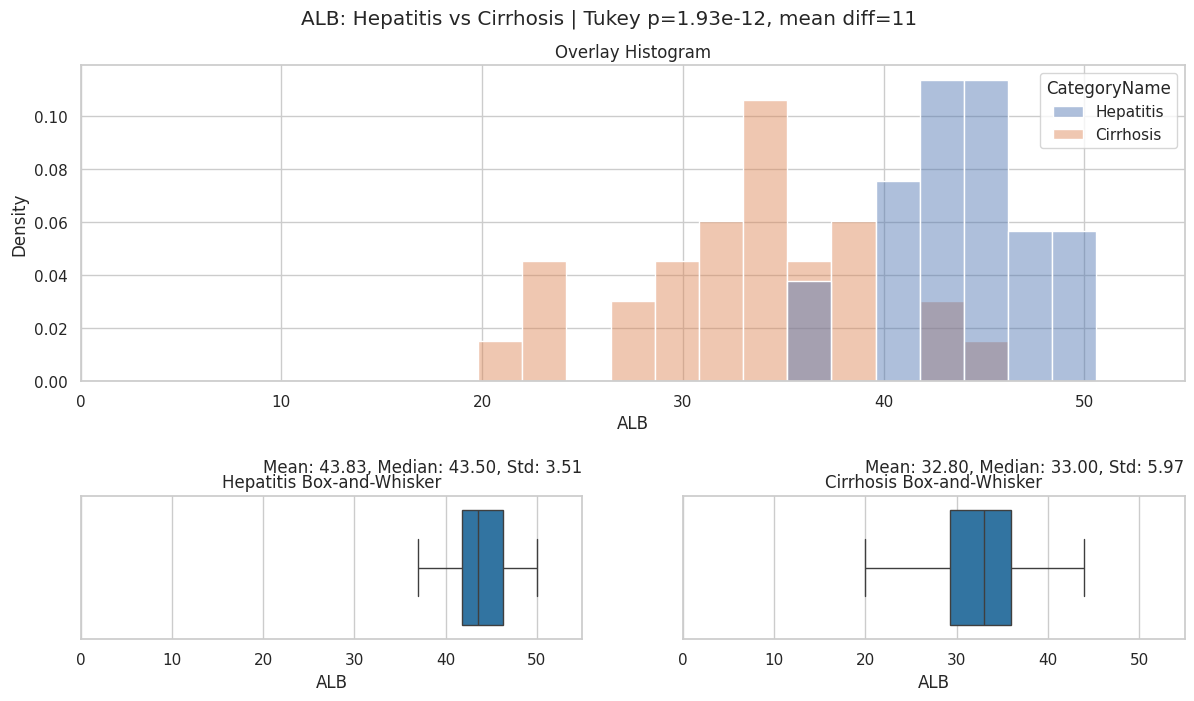

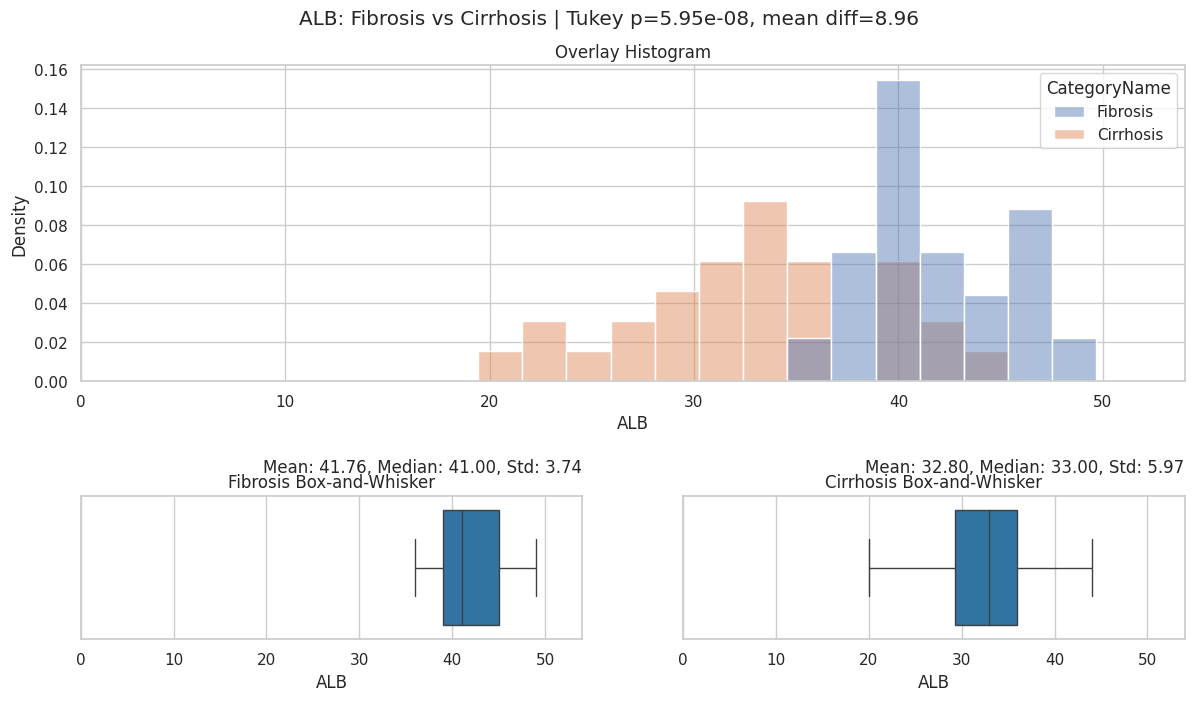

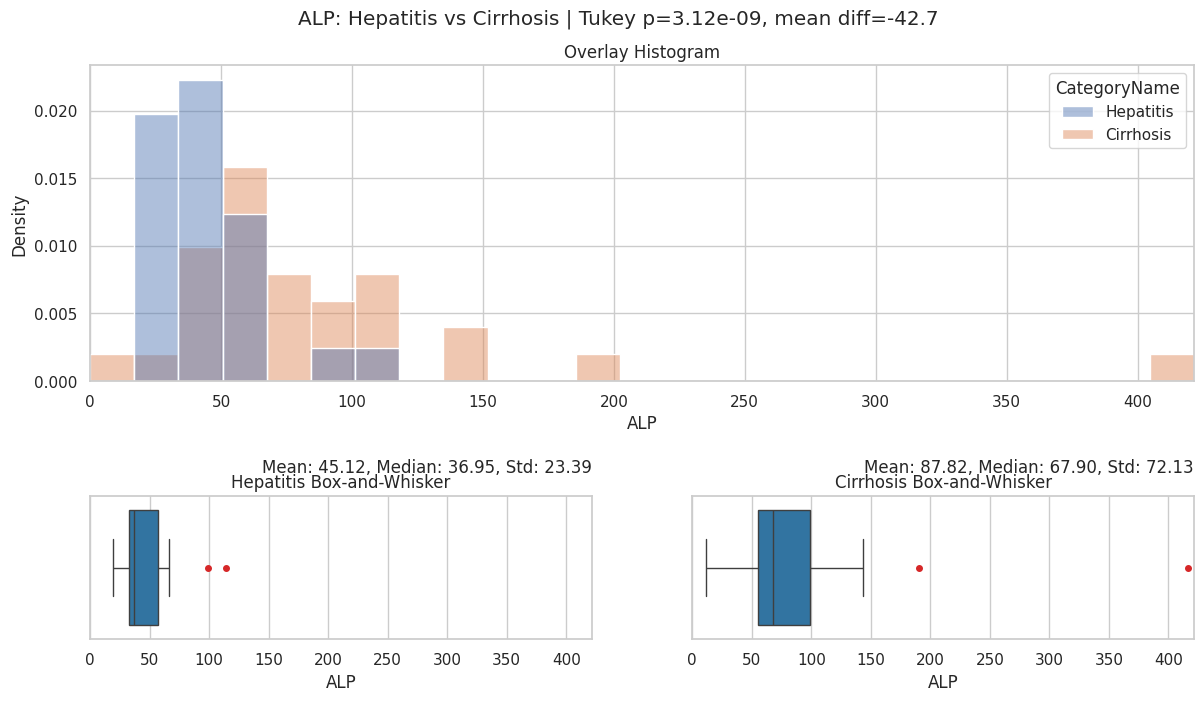

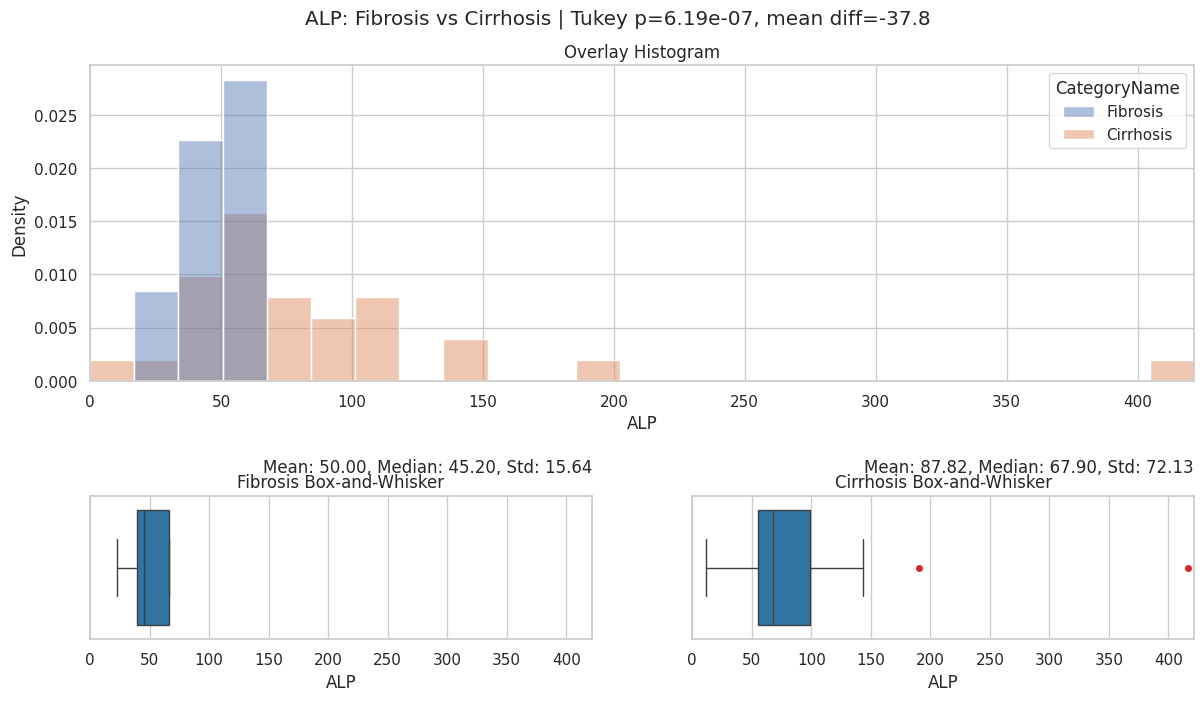

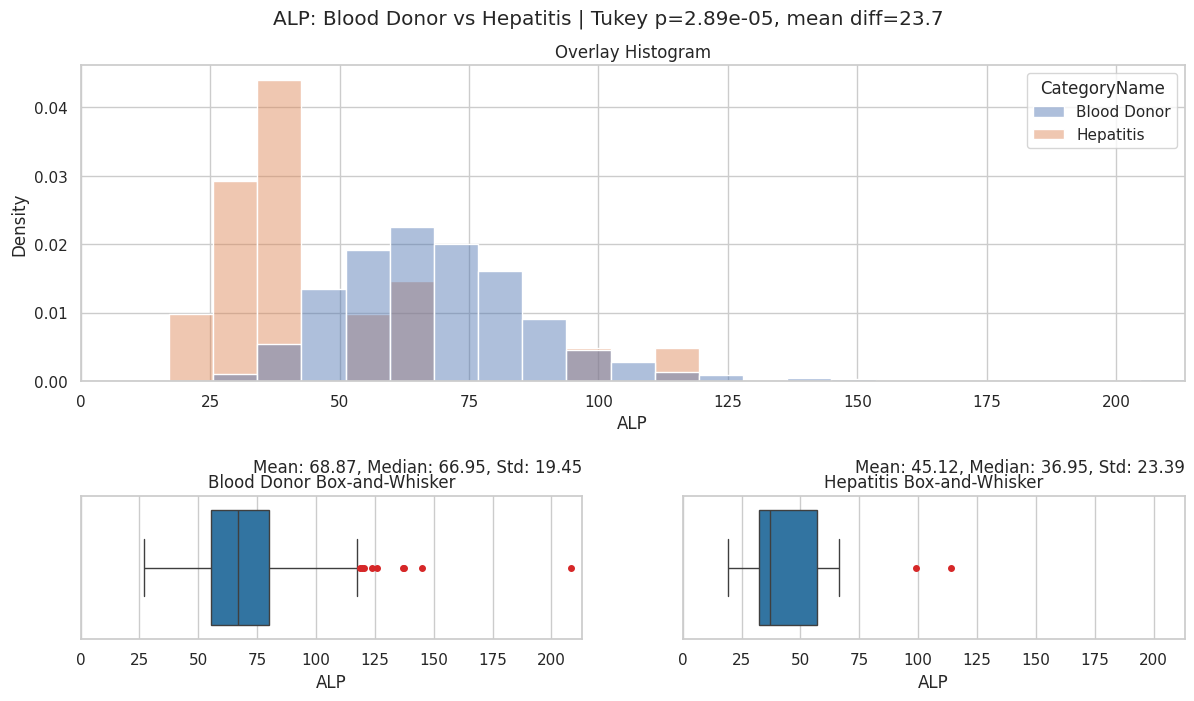

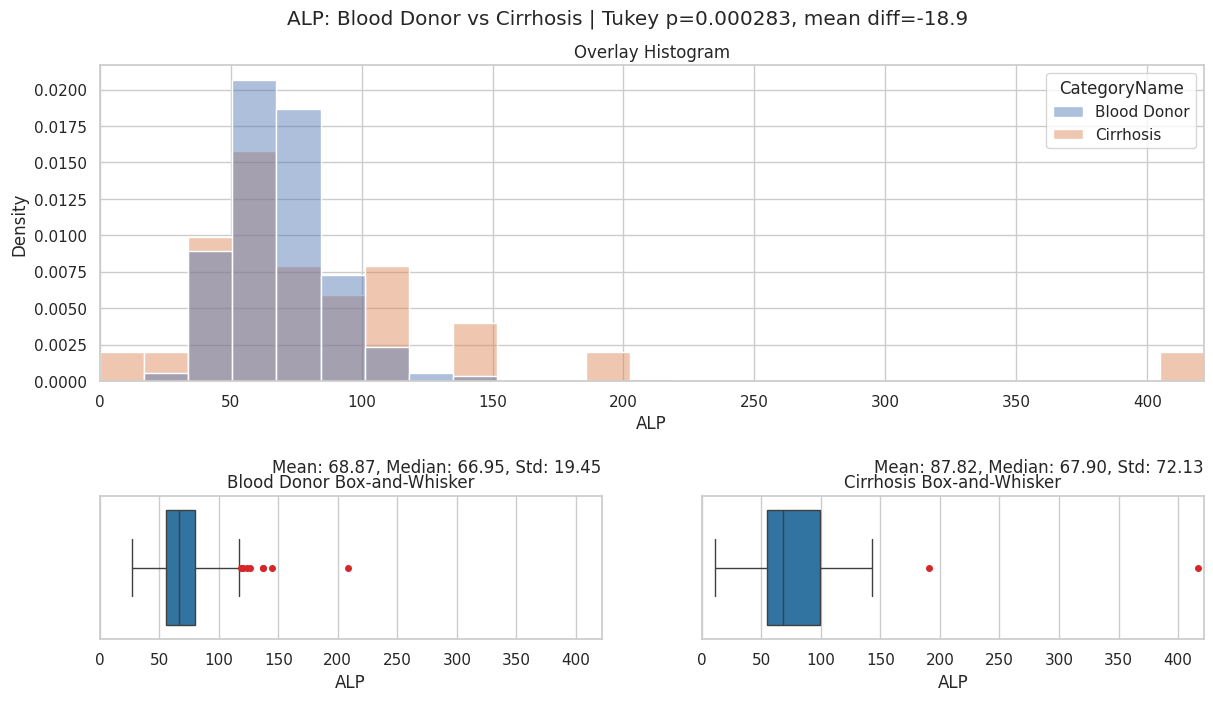

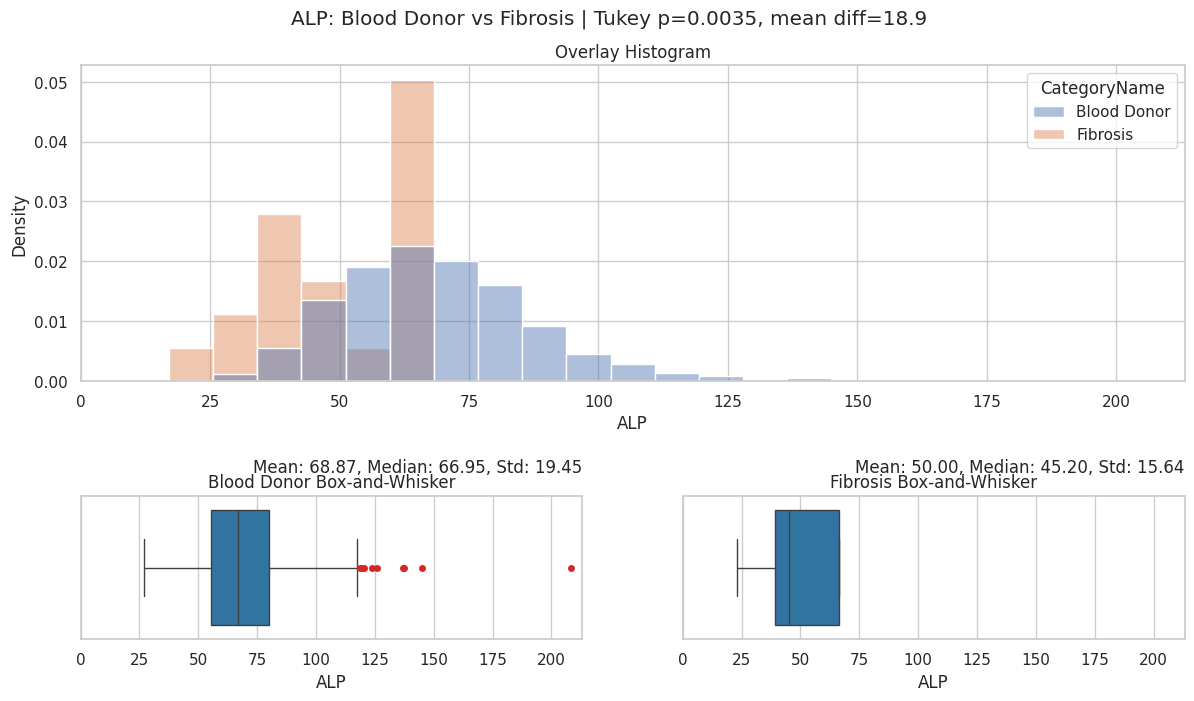

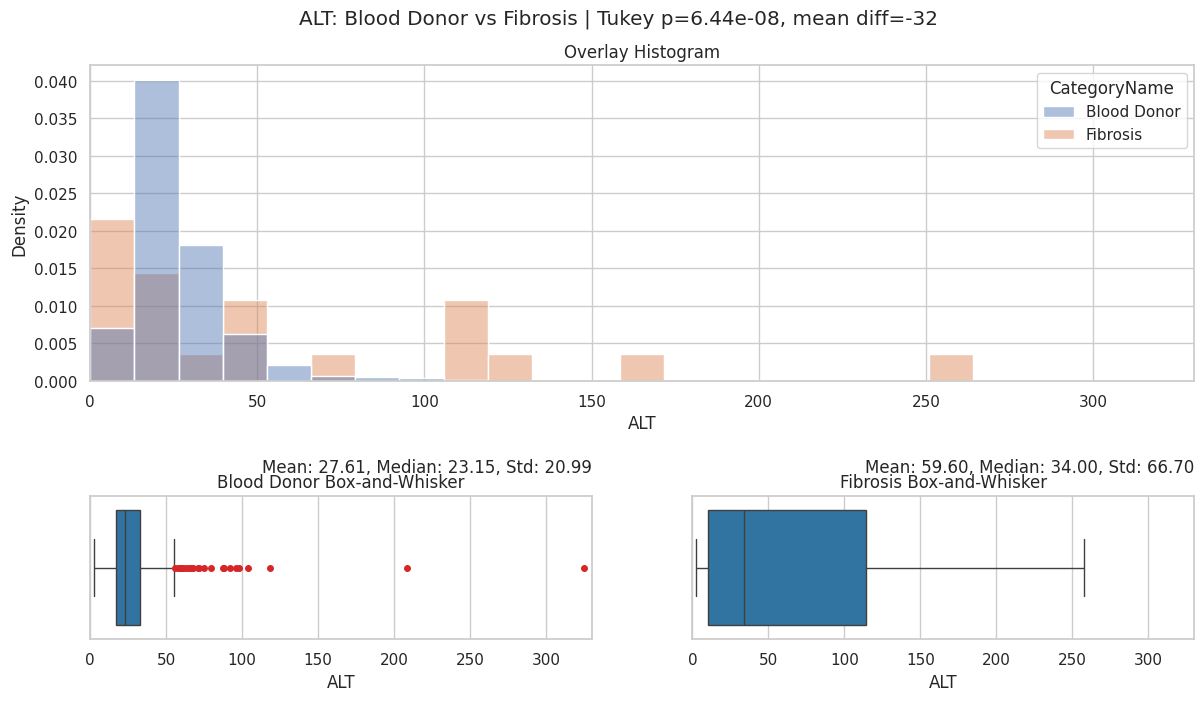

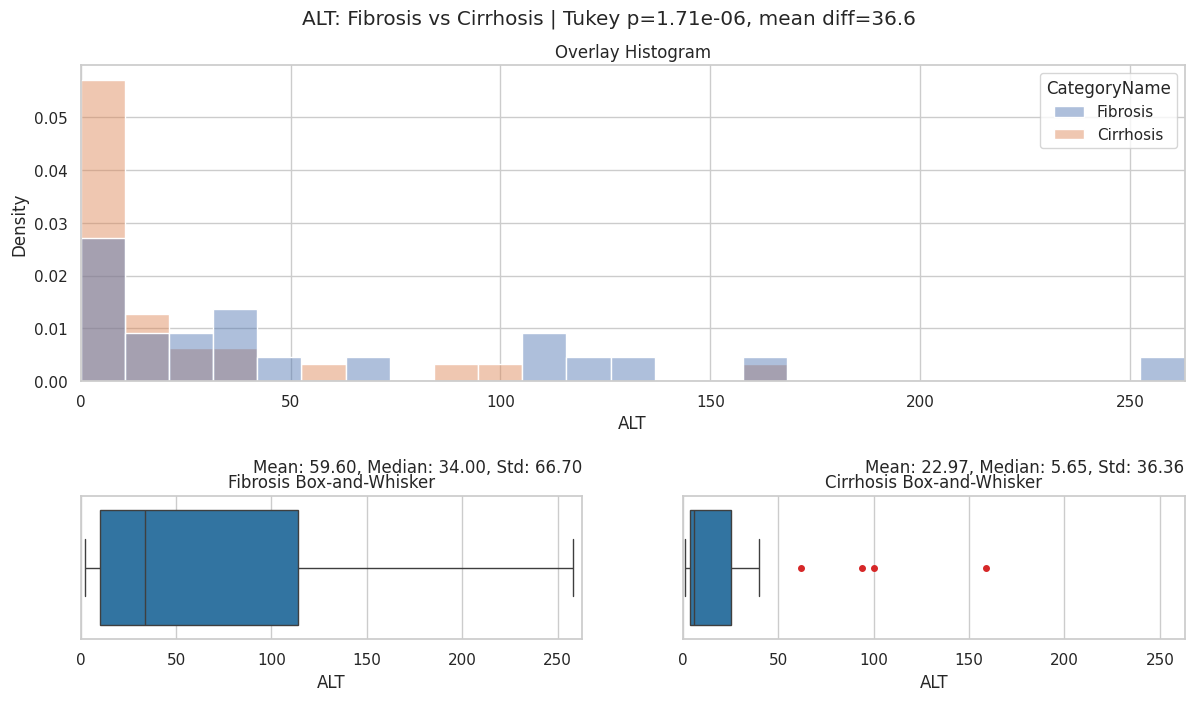

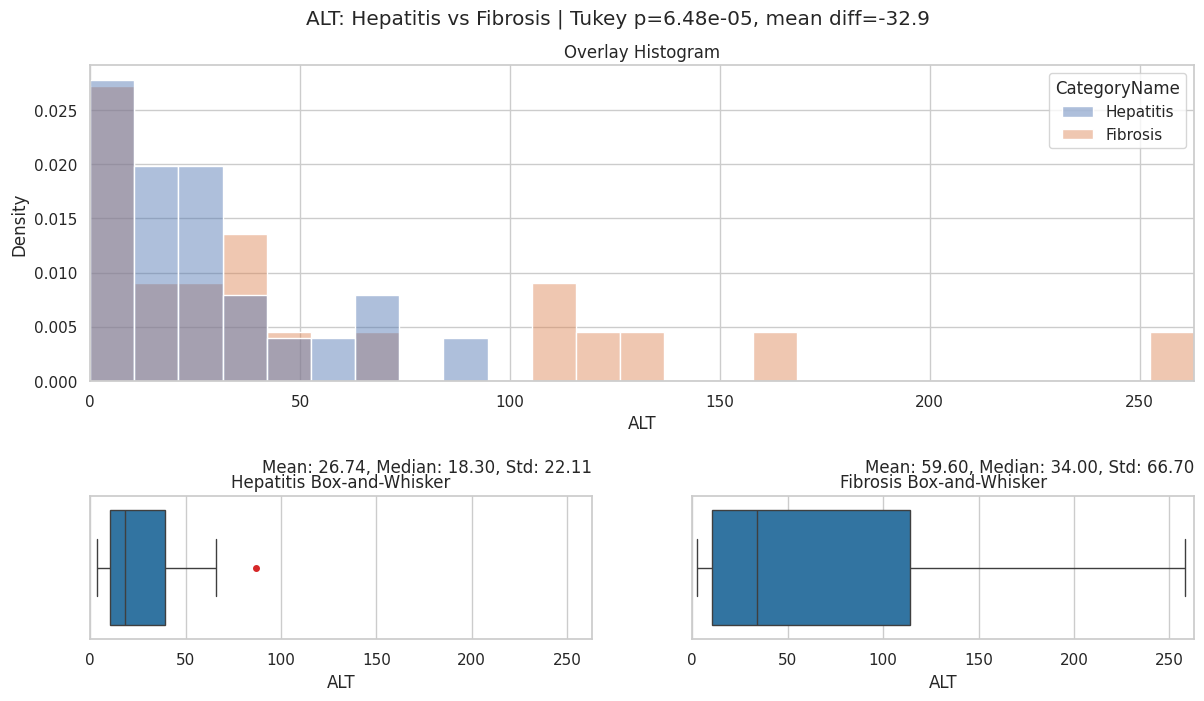

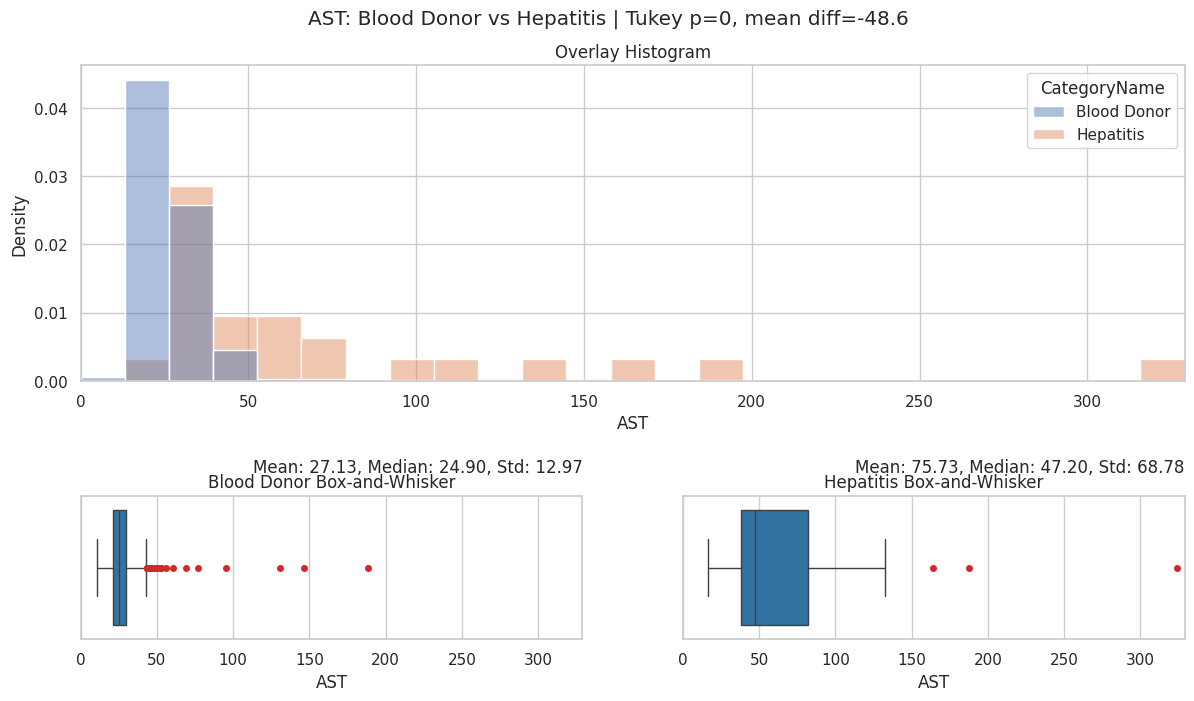

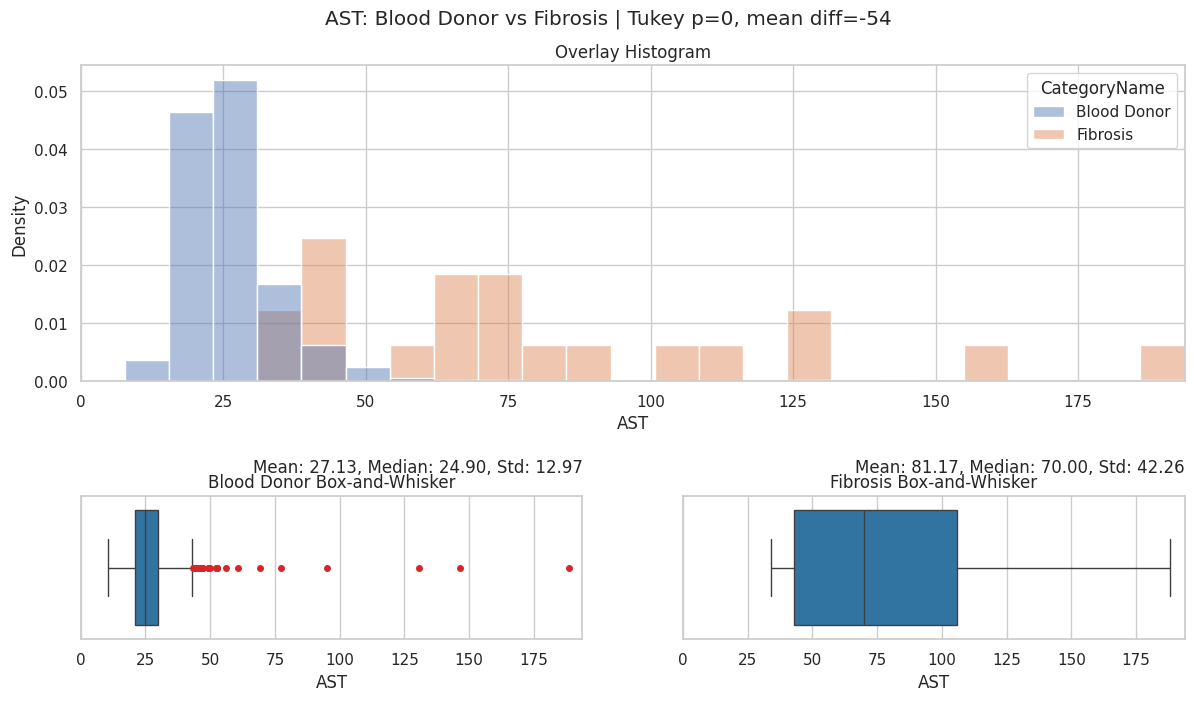

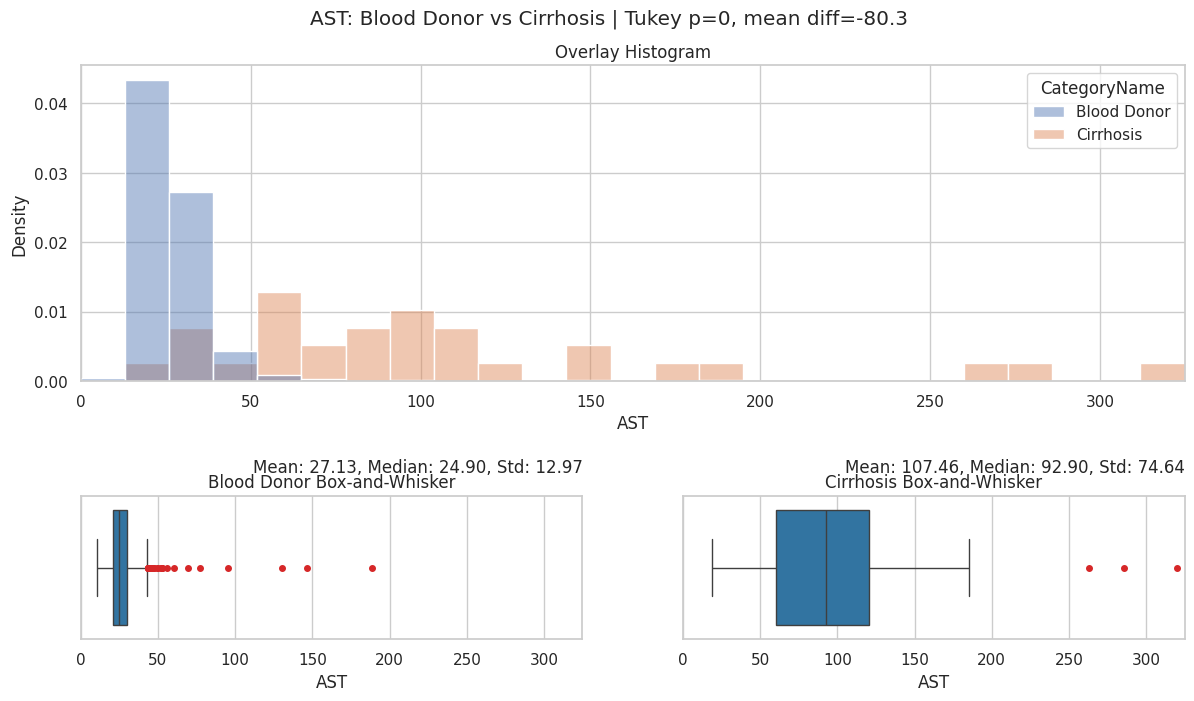

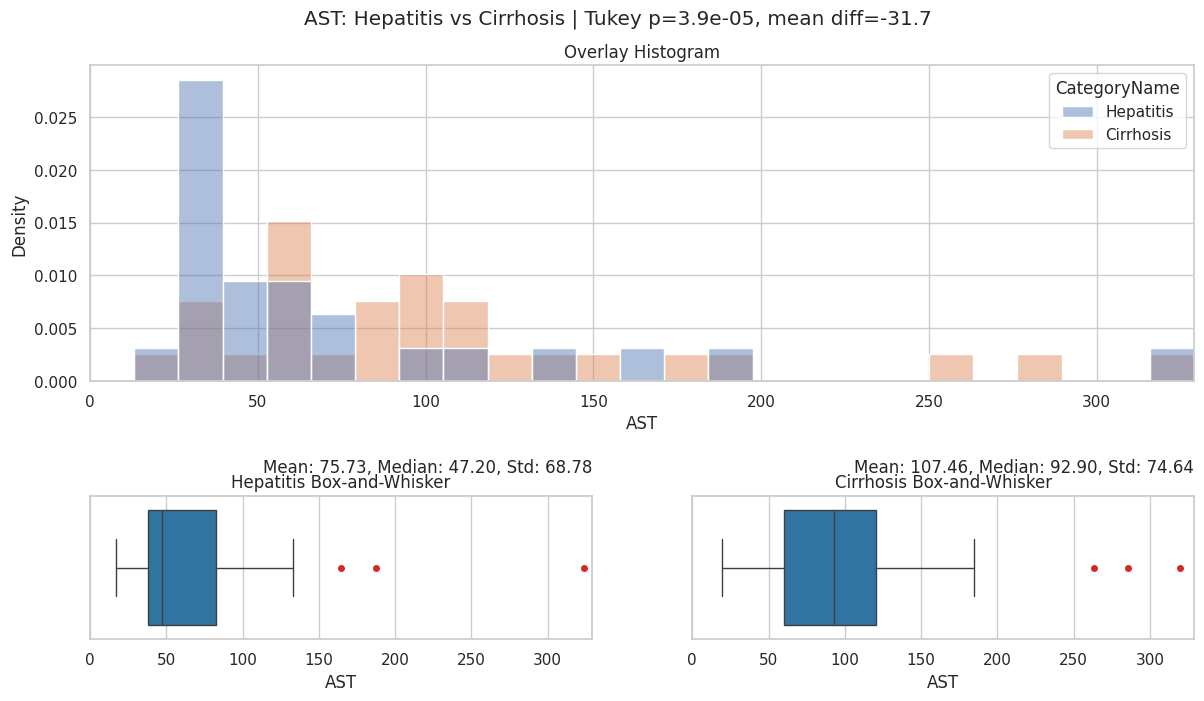

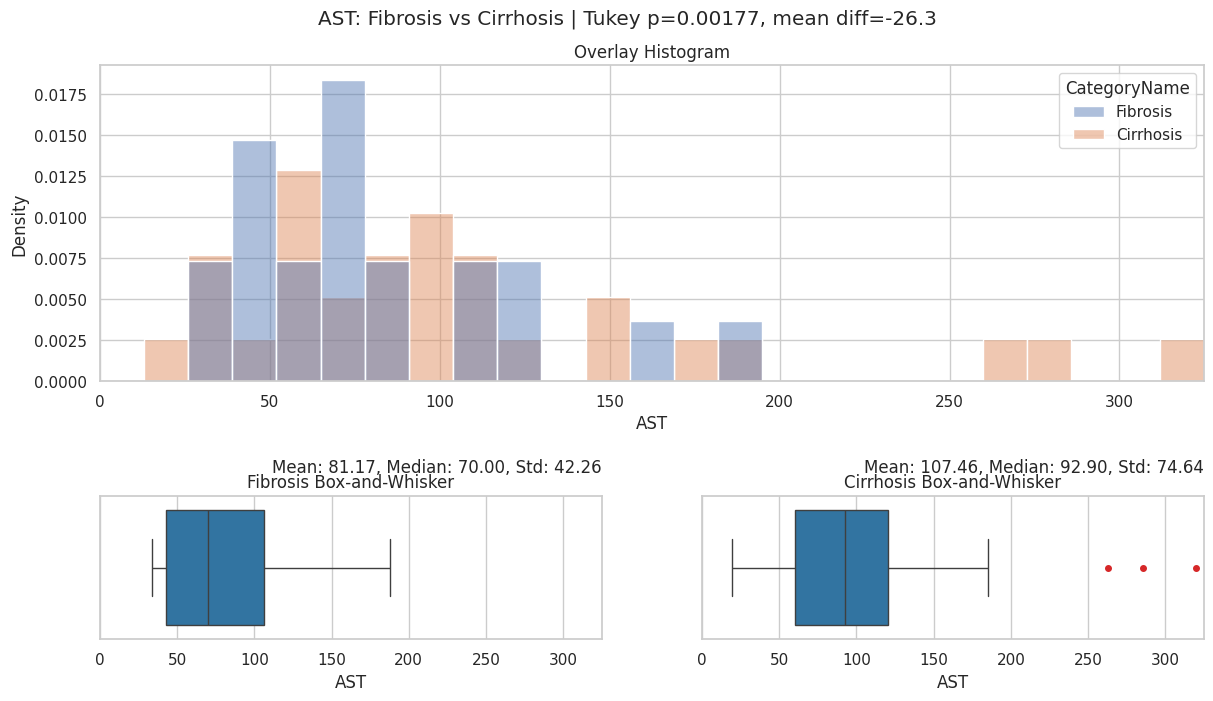

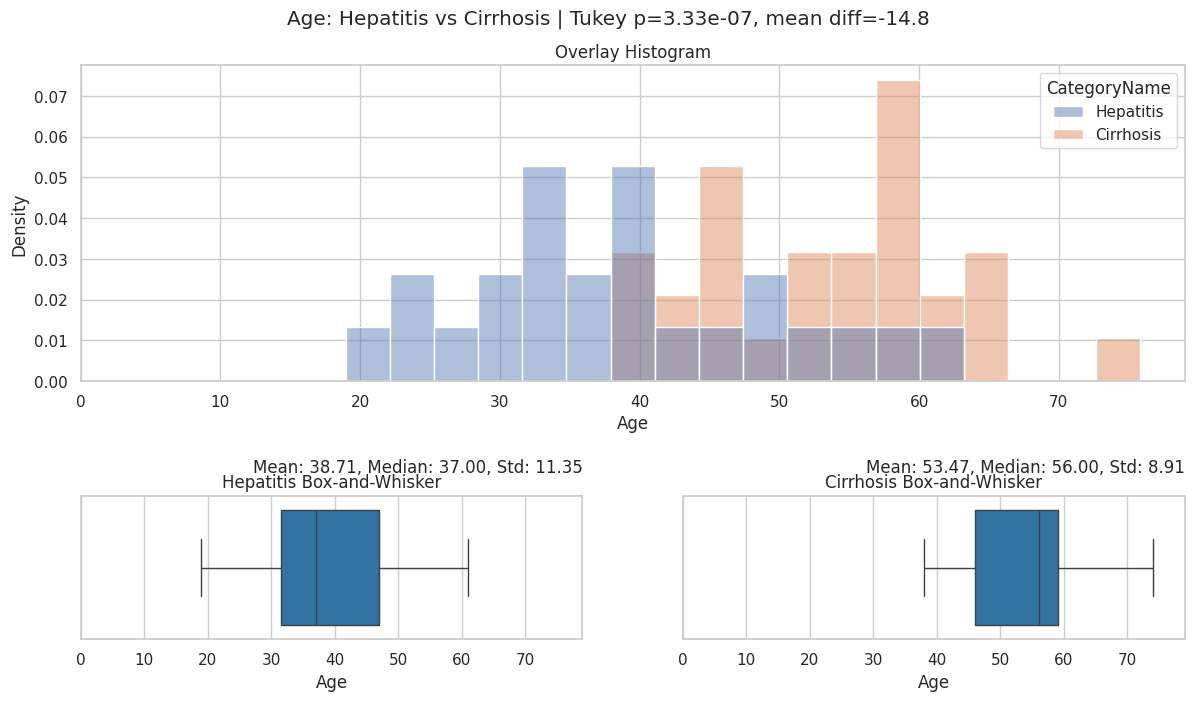

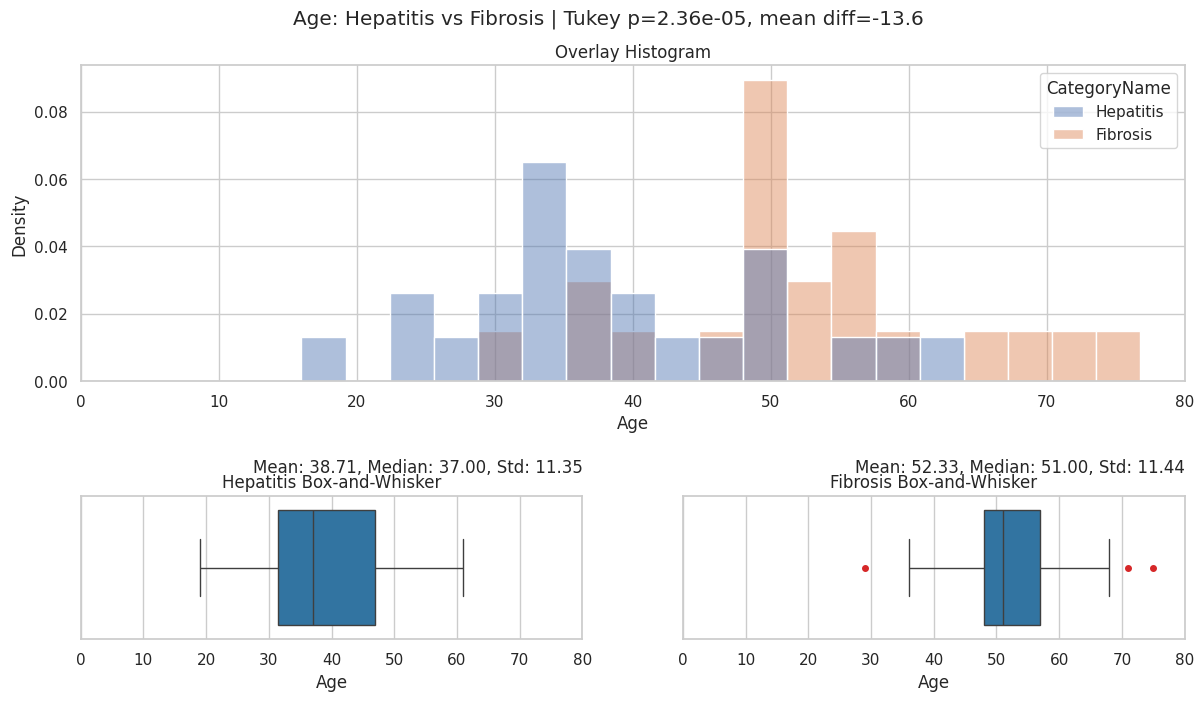

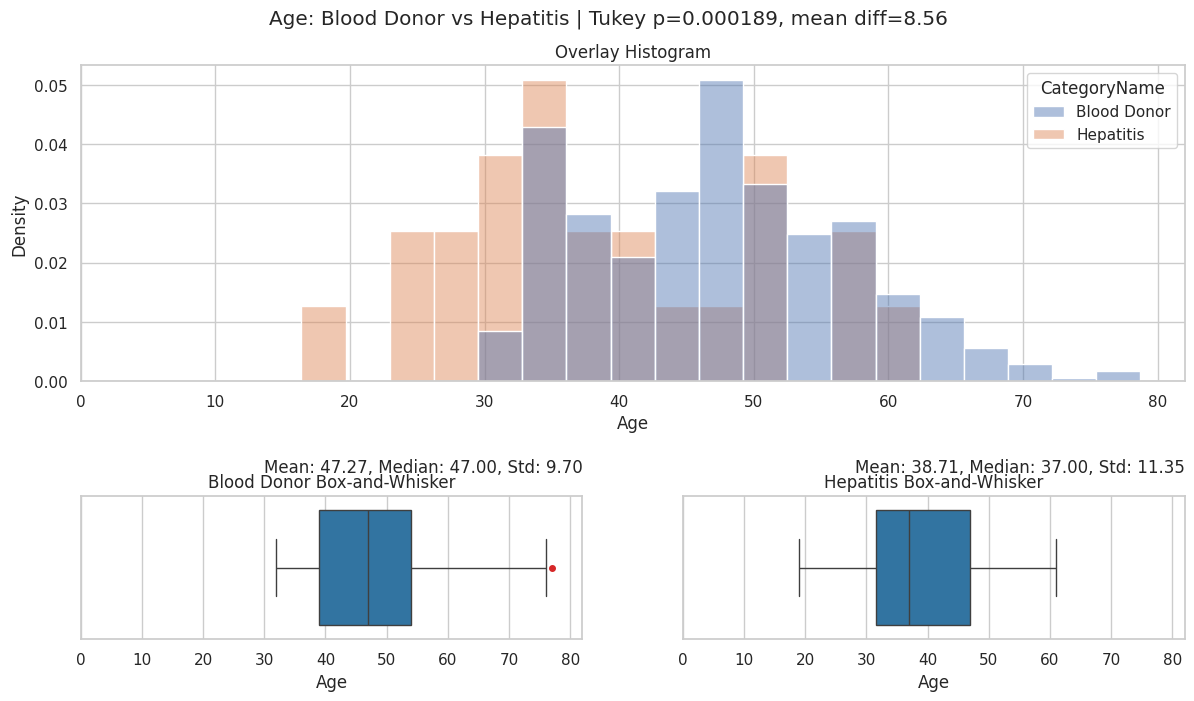

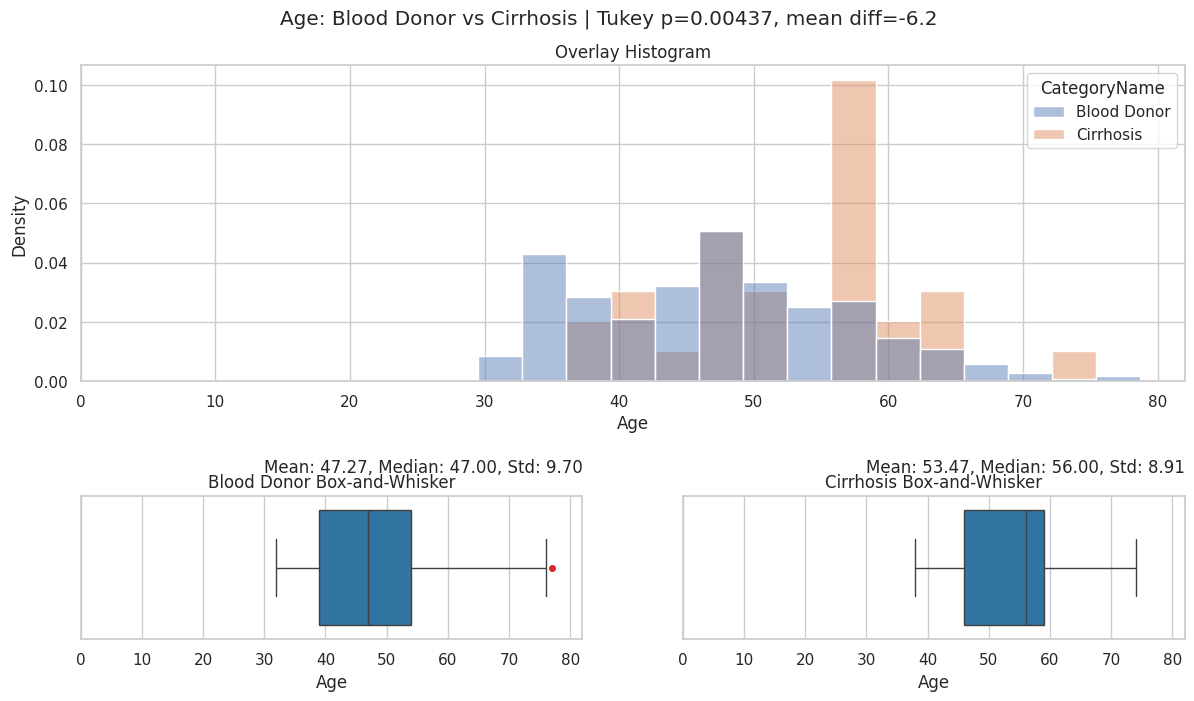

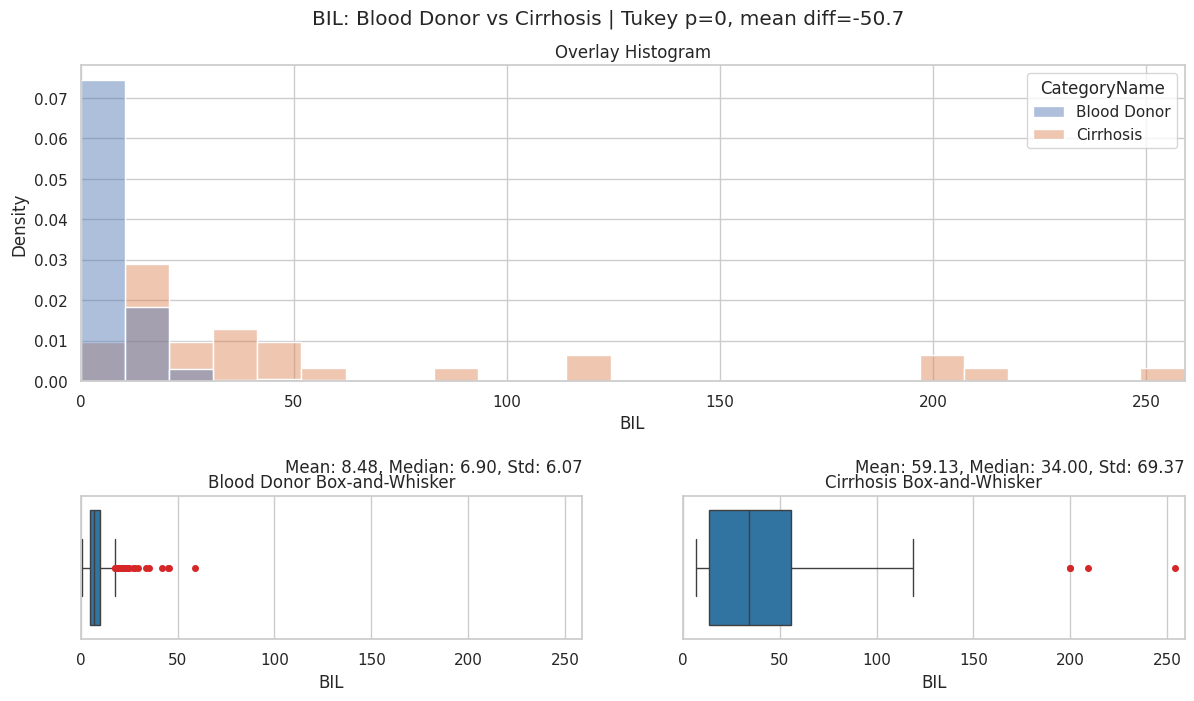

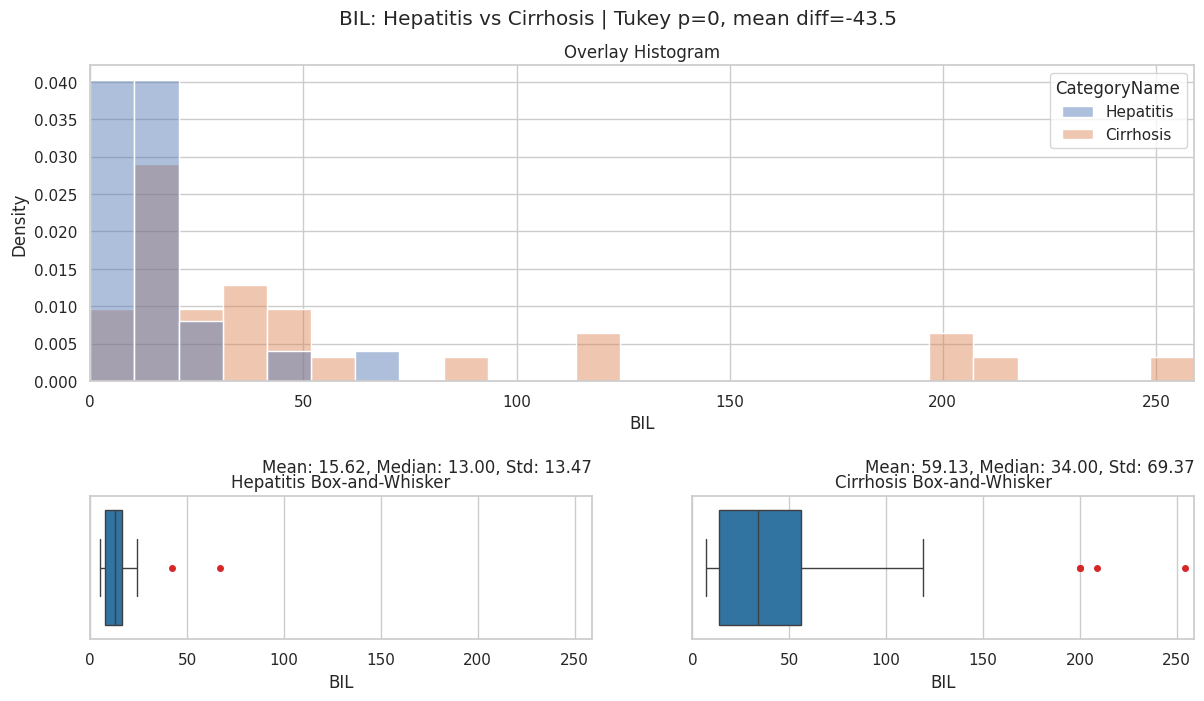

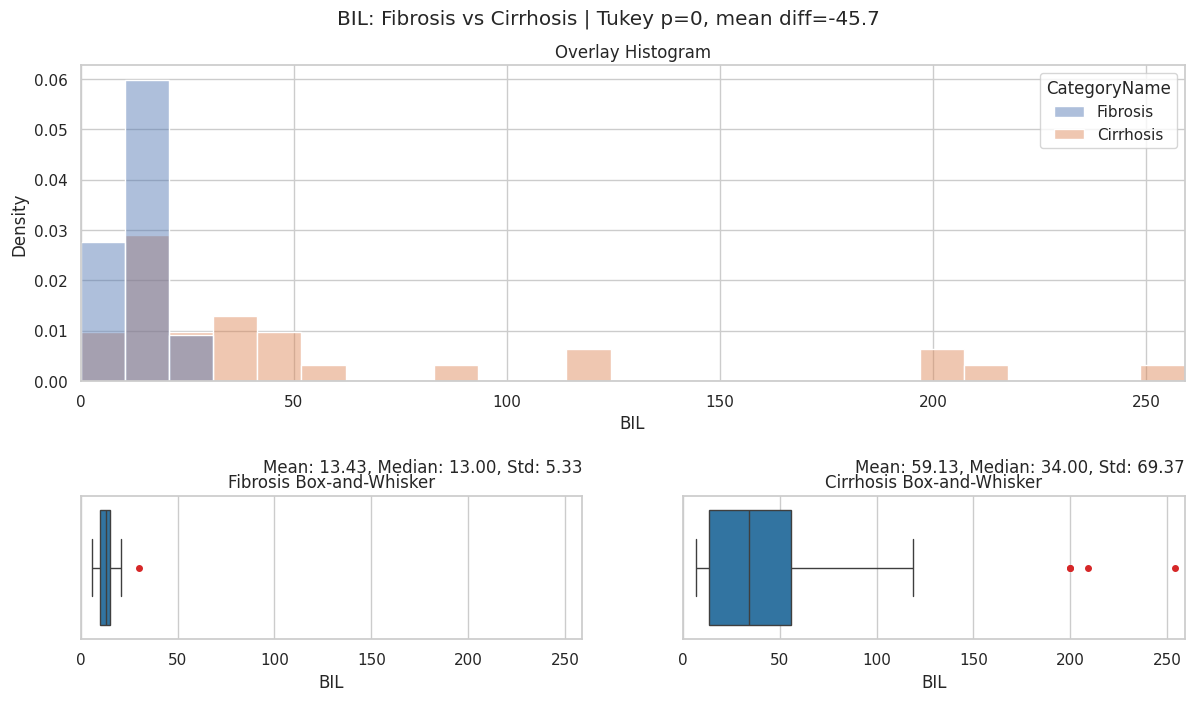

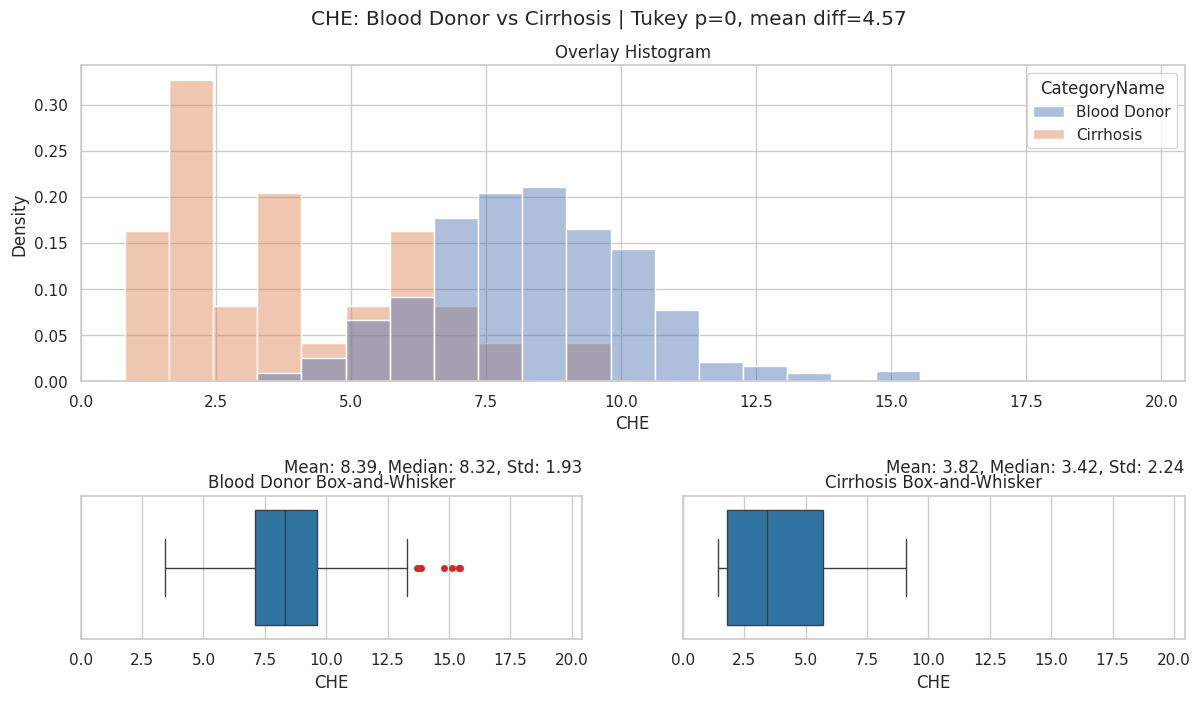

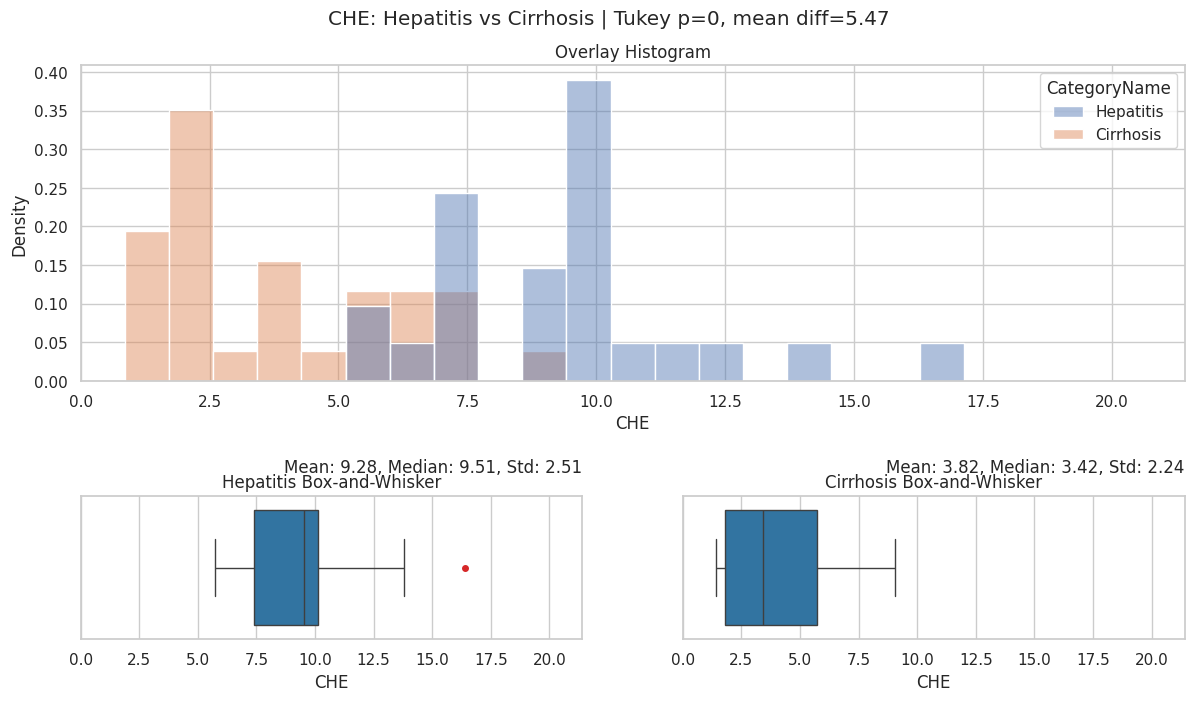

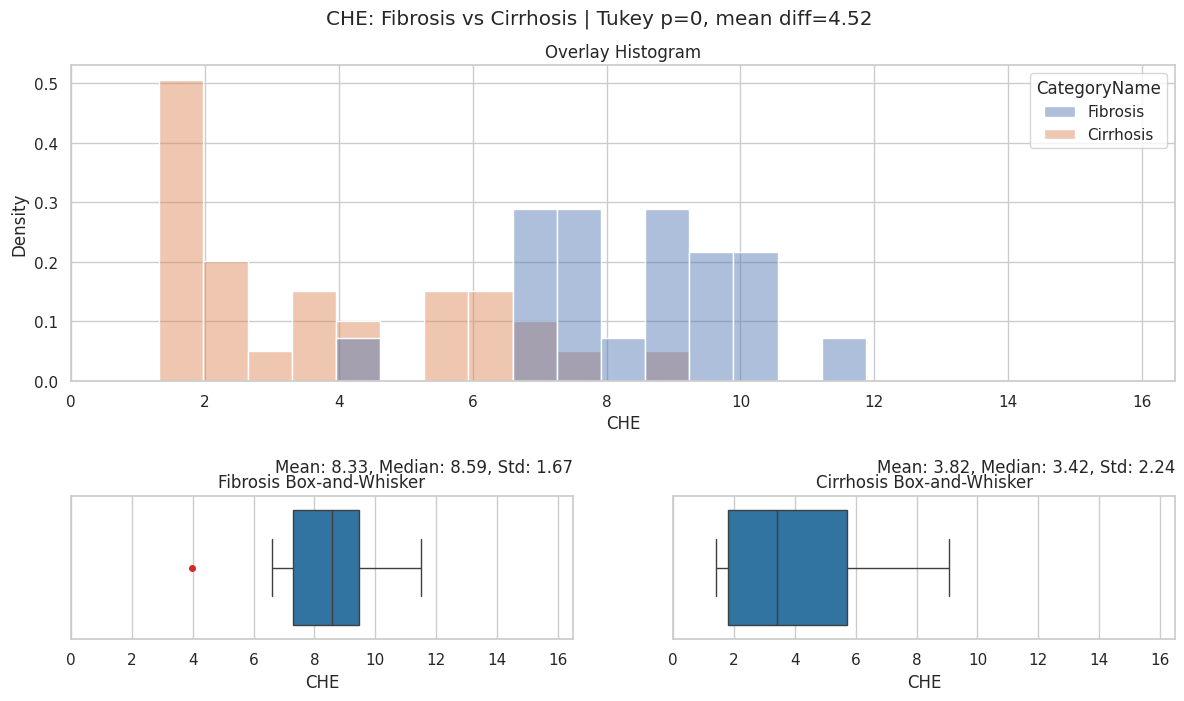

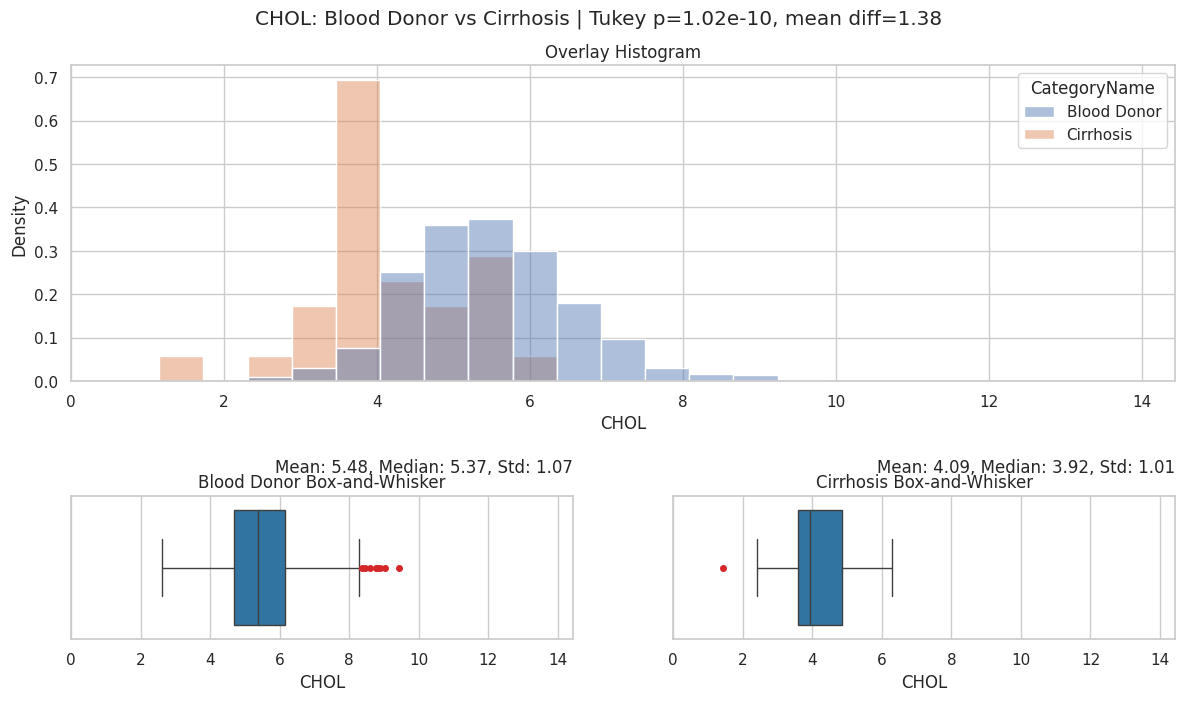

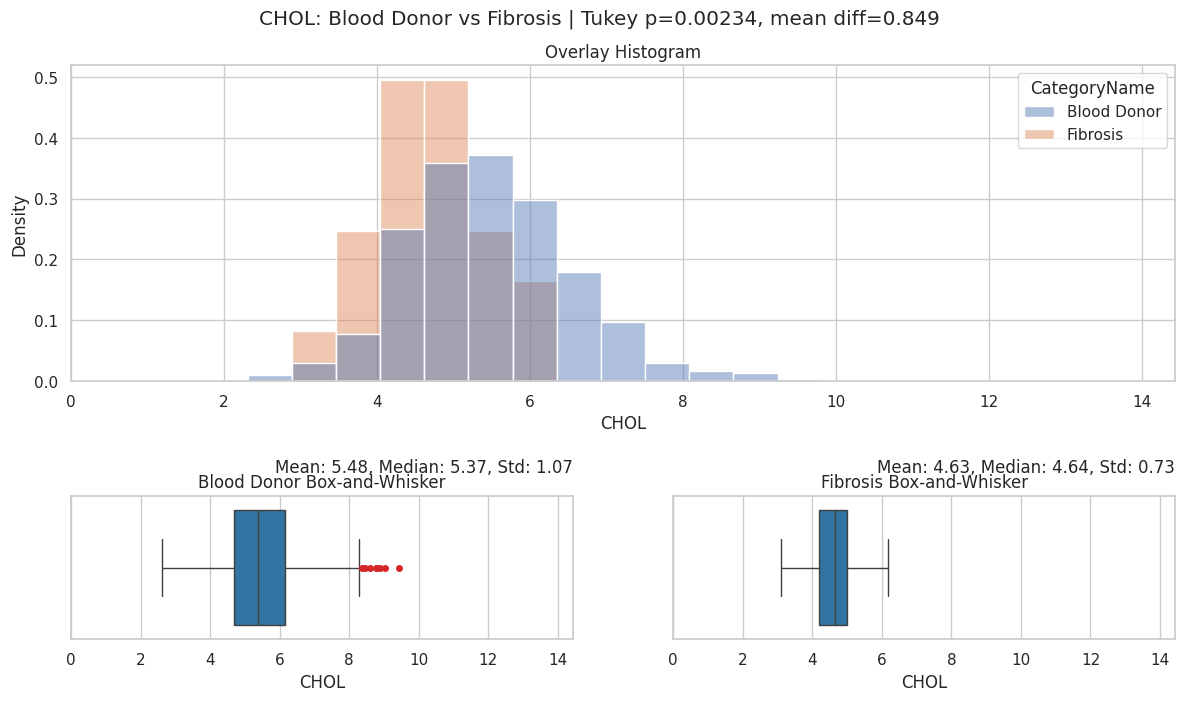

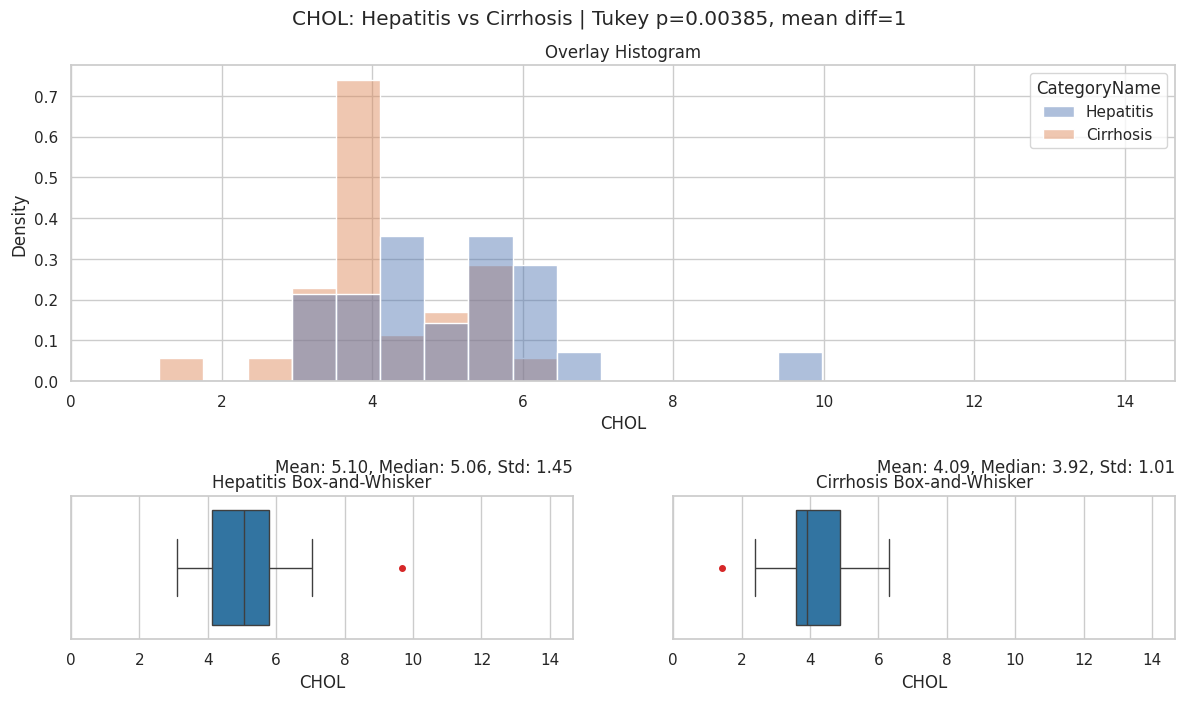

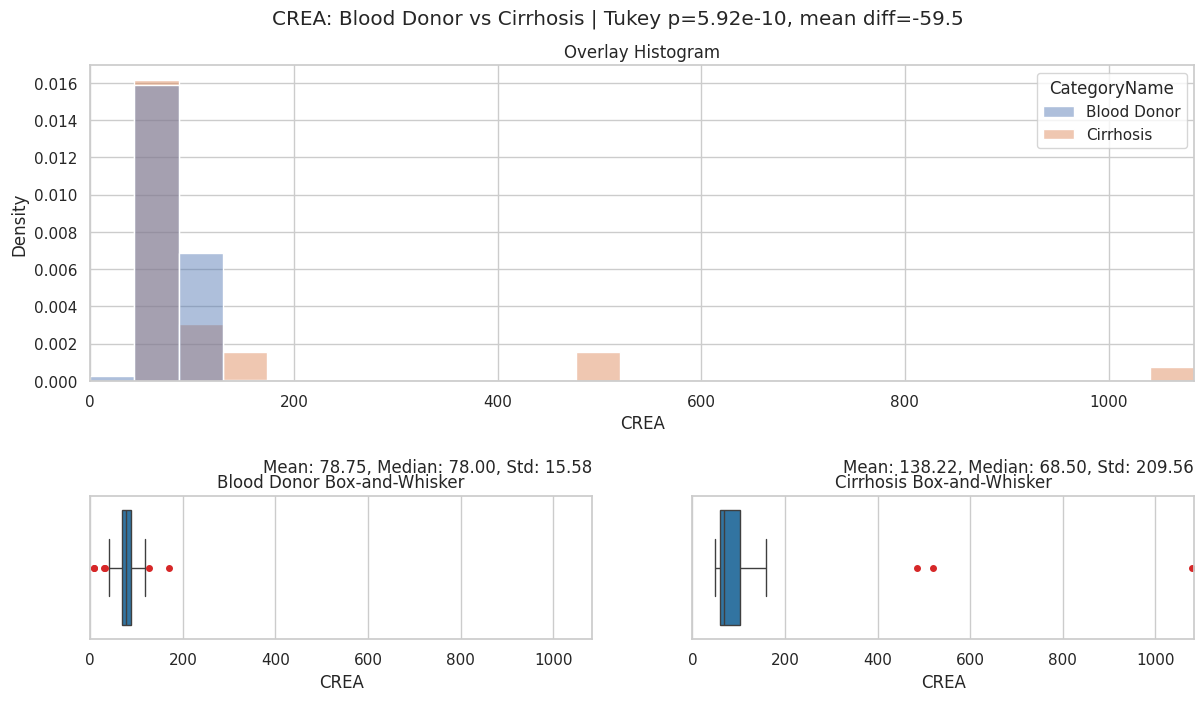

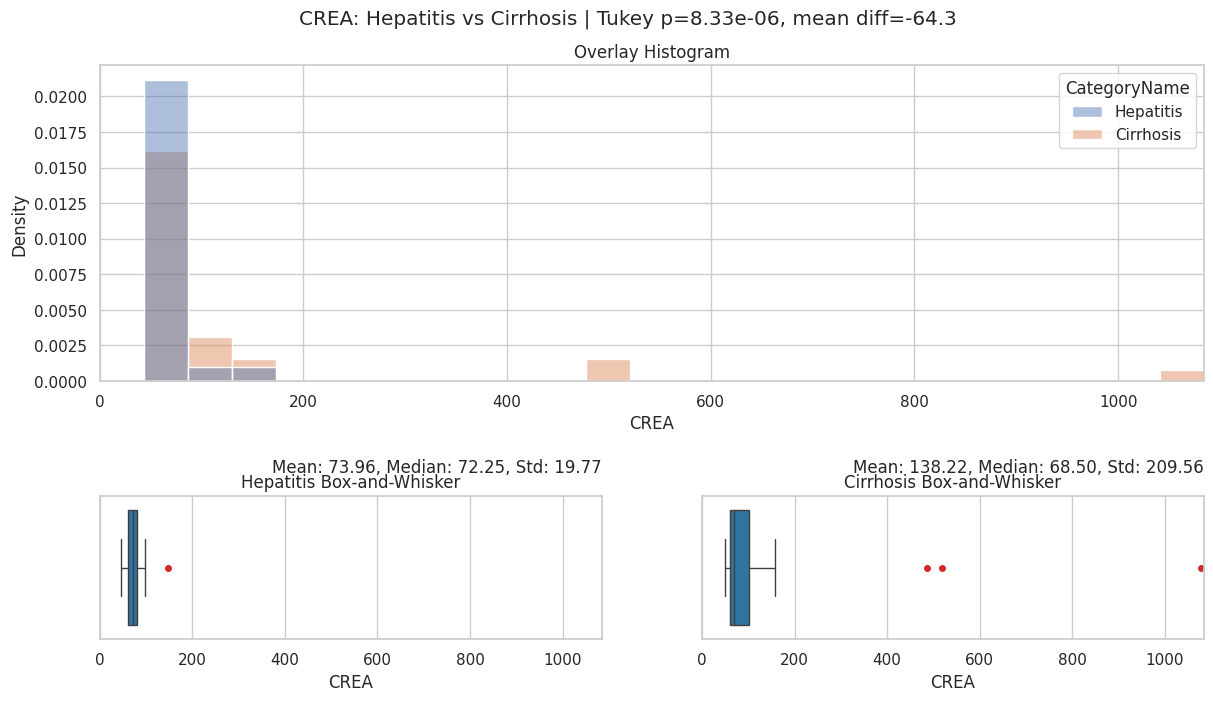

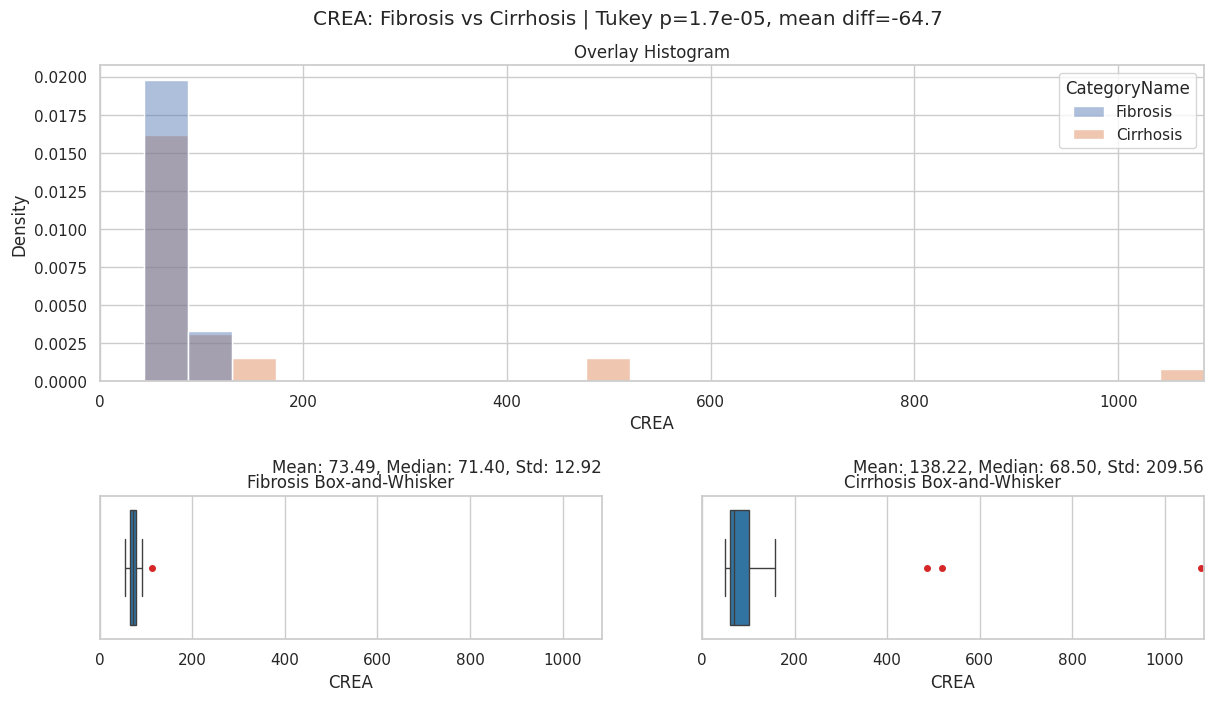

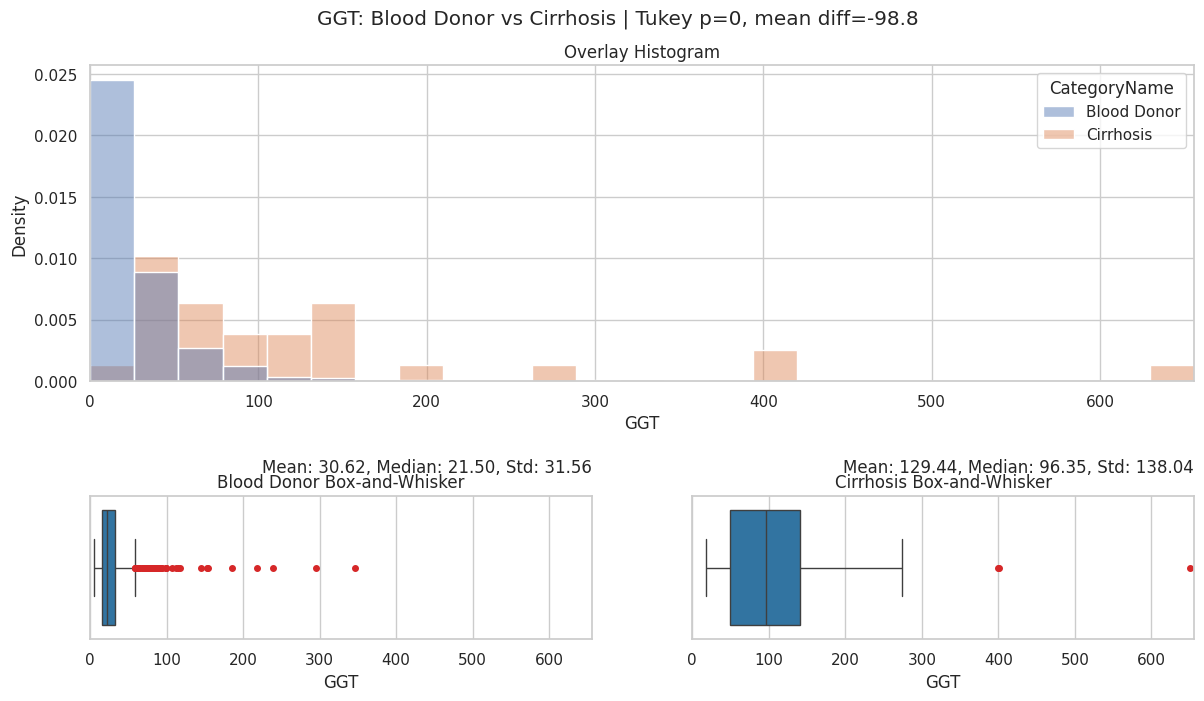

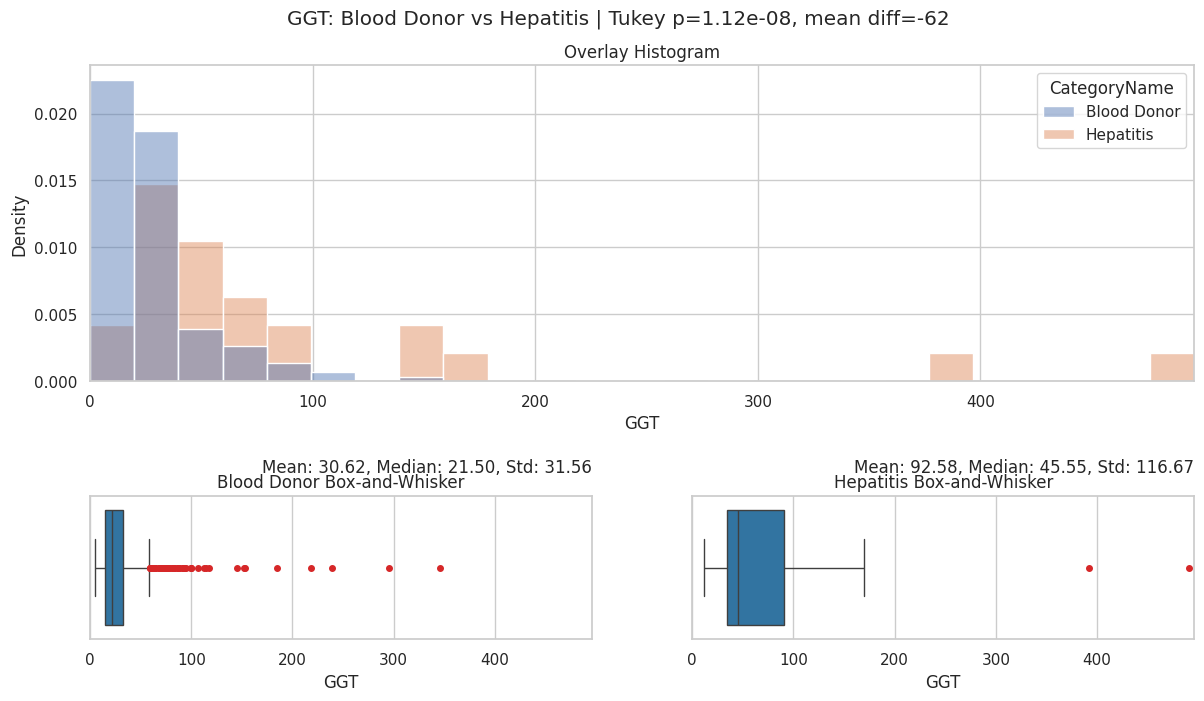

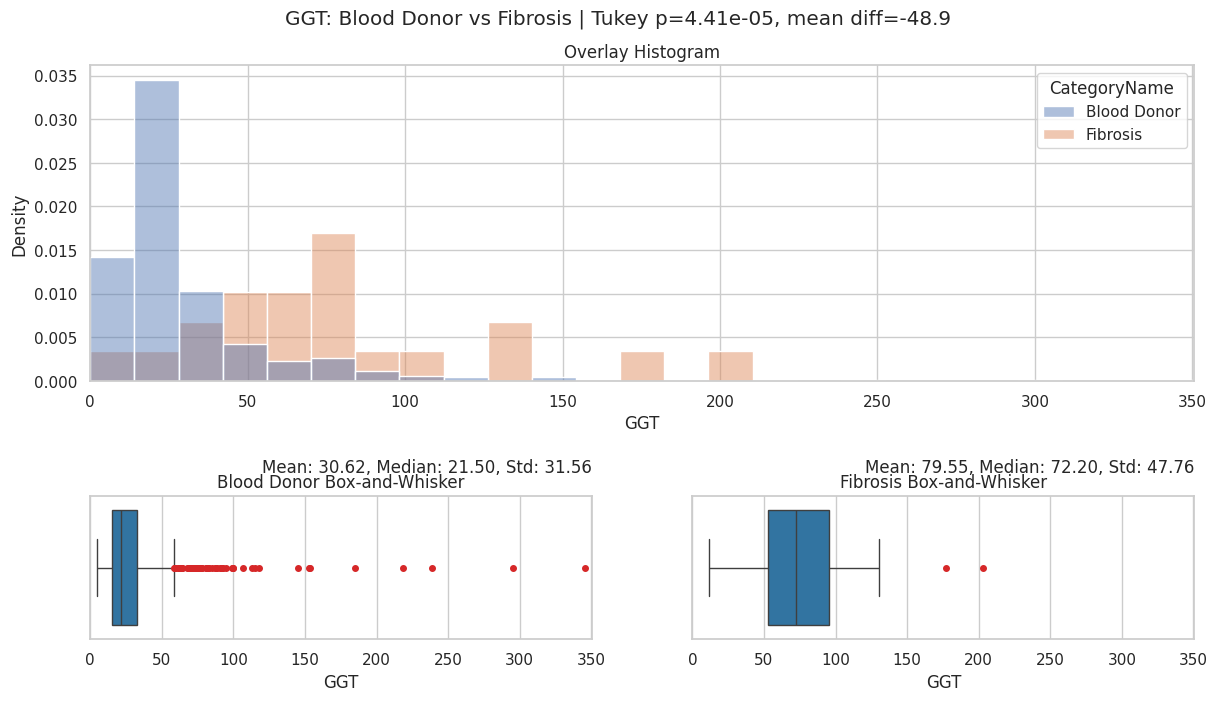

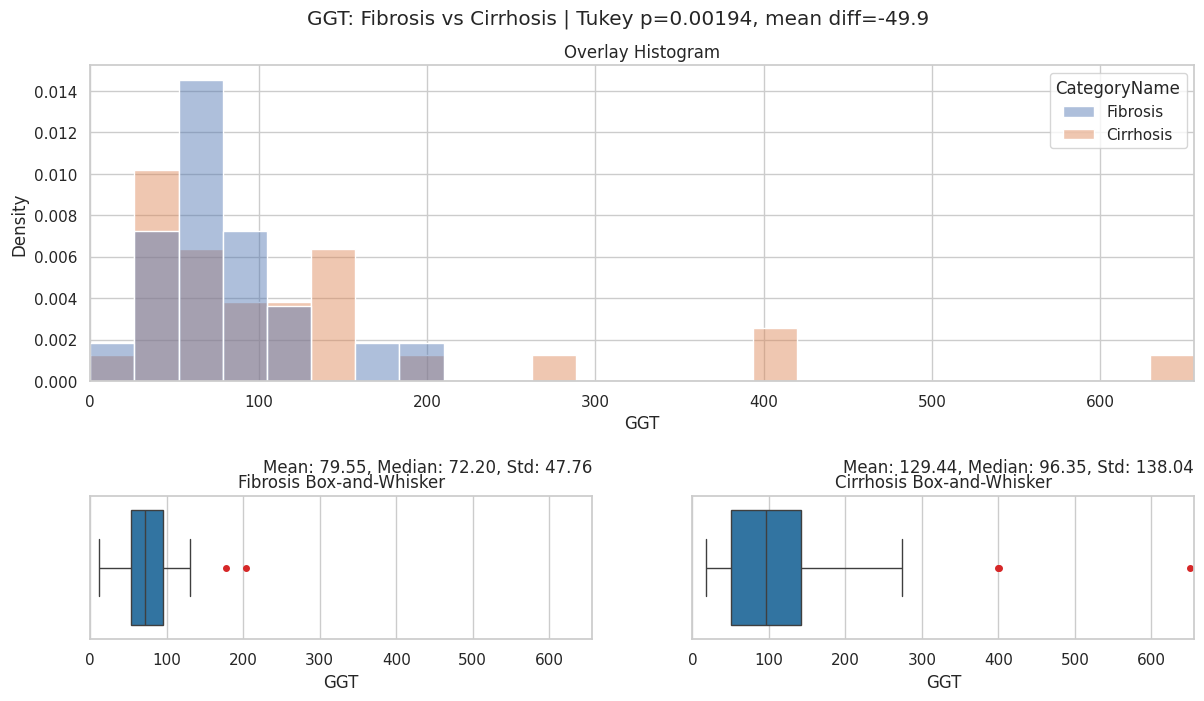

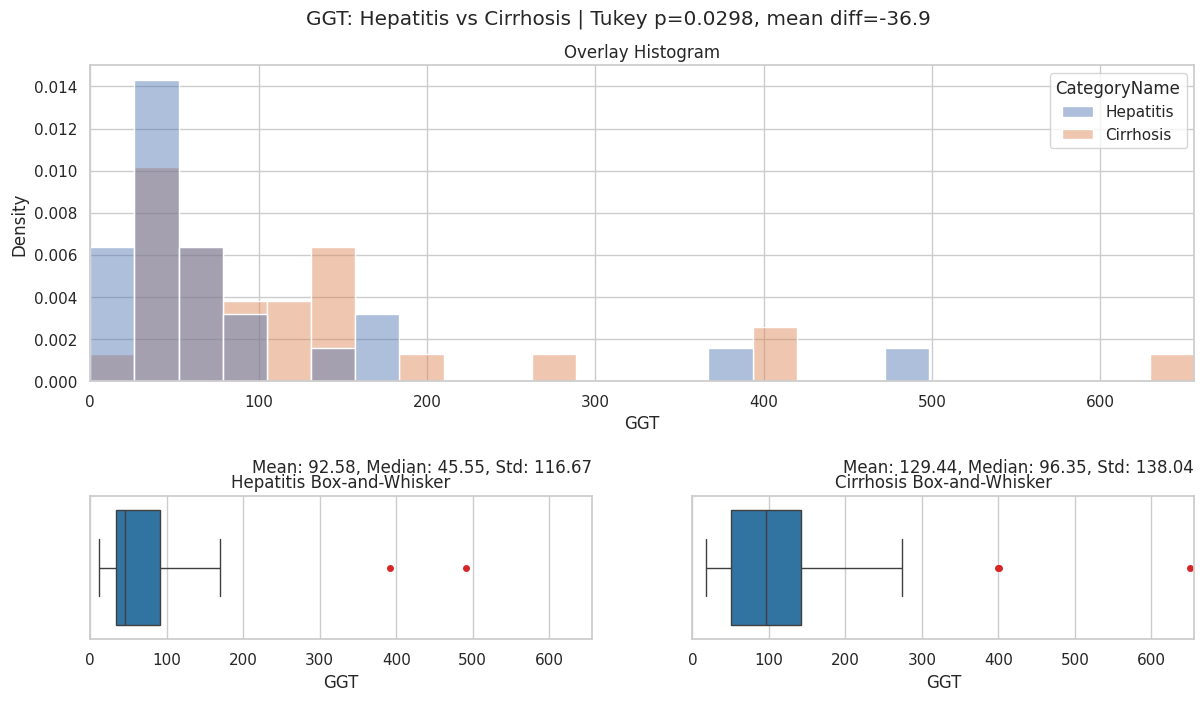

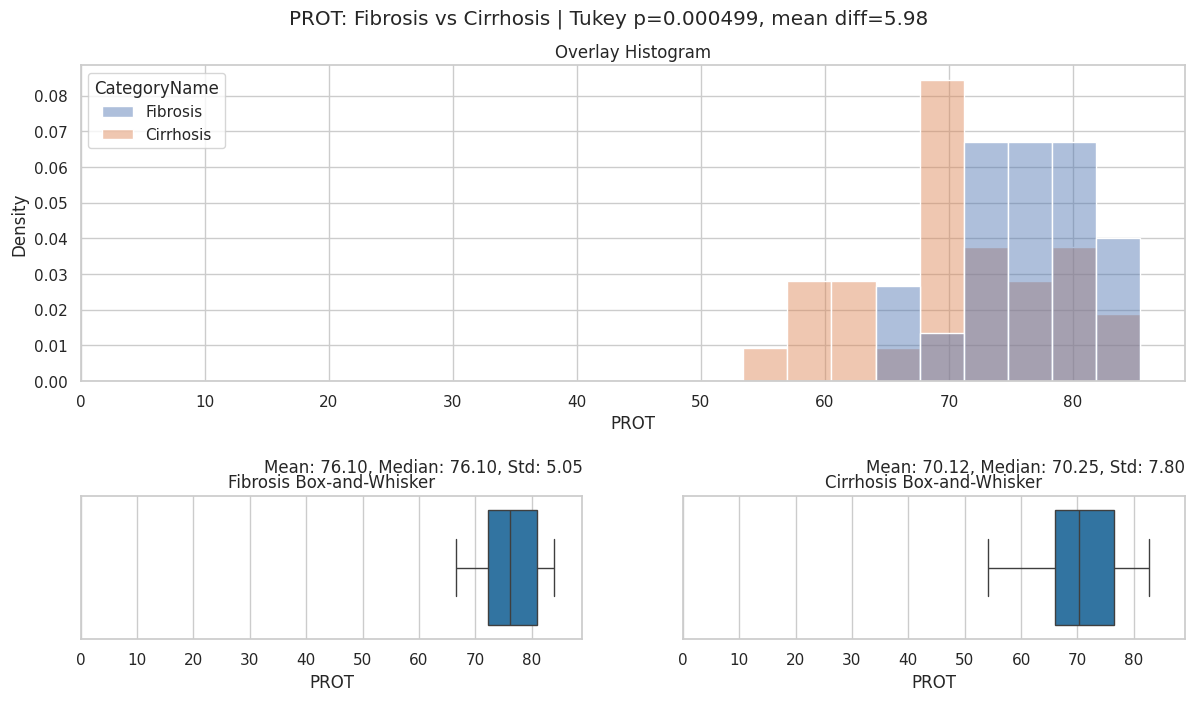

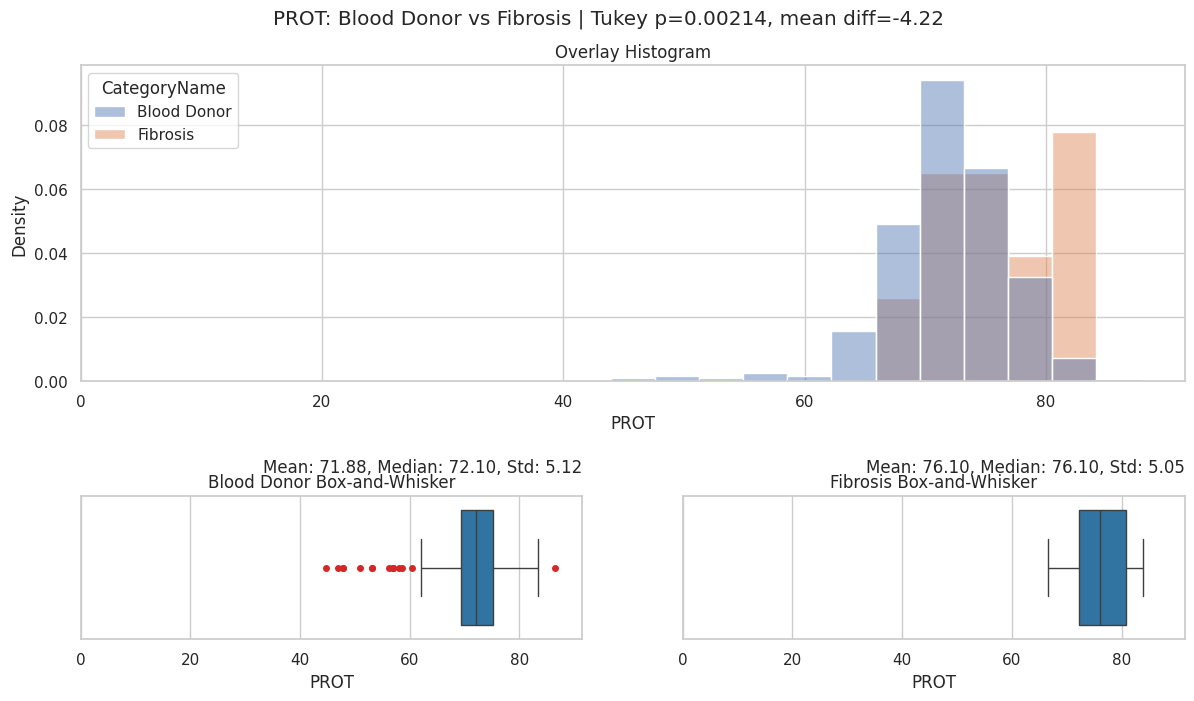

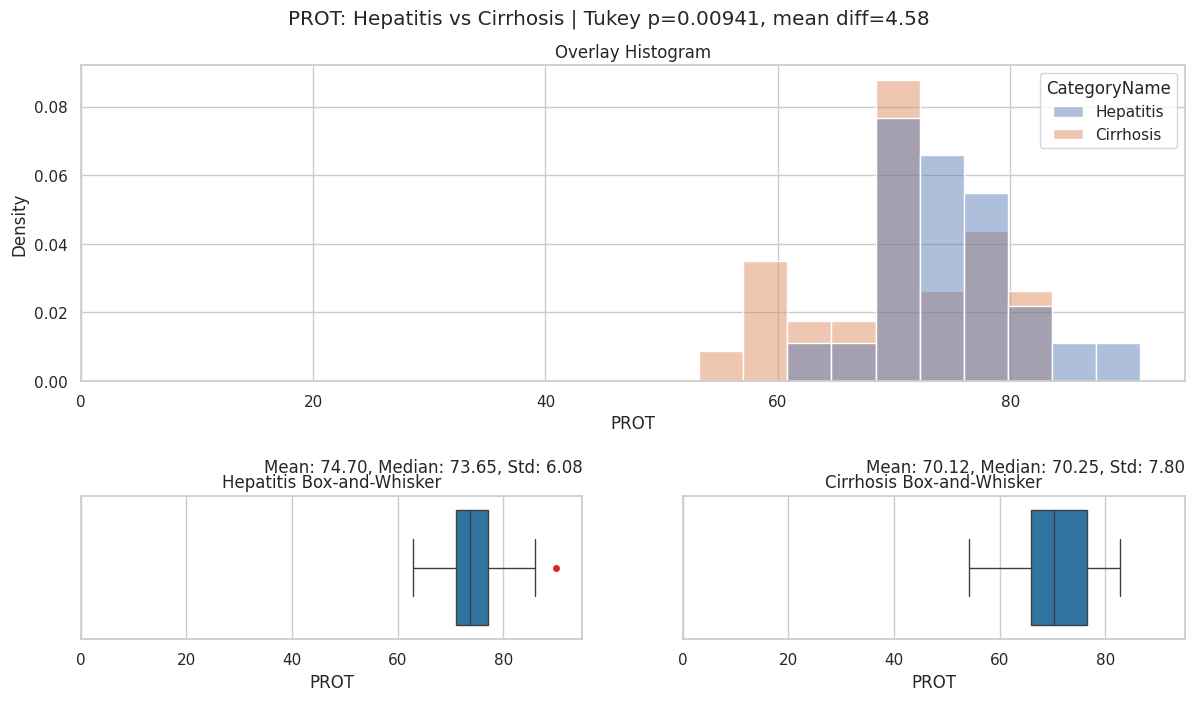

In [99]:
# Now we create plots for all (40) significant Tukey post hoc comparisons

sig_posthoc = posthoc_df[posthoc_df["p_tukey"] < 0.05].copy()
sig_posthoc = sig_posthoc.sort_values(["Feature", "p_tukey"])

print(f"Significant comparisons to plot: {len(sig_posthoc)}")

for _, row in sig_posthoc.iterrows():
    feat = row["Feature"]
    g1 = row["Group1"]
    g2 = row["Group2"]
    pval = row["p_tukey"]
    mdiff = row["Mean_diff"]

    sub = df_test[df_test["CategoryName"].isin([g1, g2])][["CategoryName", feat]].dropna().copy()
    g1_vals = sub.loc[sub["CategoryName"] == g1, feat]
    g2_vals = sub.loc[sub["CategoryName"] == g2, feat]

    data_min = min(g1_vals.min(), g2_vals.min())
    data_max = max(g1_vals.max(), g2_vals.max())

    x_lower = min(data_min, 0)
    x_upper = data_max + 5

    # Use fixed bin edges so the histogram spans the same full range as the box plots.
    hist_bins = np.linspace(x_lower, x_upper, 26)

    fig = plt.figure(figsize=(12, 7))
    gs = fig.add_gridspec(2, 2, height_ratios=[2.2, 1], hspace=0.5, wspace=0.2)

    ax_hist = fig.add_subplot(gs[0, :])
    ax_box_1 = fig.add_subplot(gs[1, 0])
    ax_box_2 = fig.add_subplot(gs[1, 1])

    fig.suptitle(f"{feat}: {g1} vs {g2} | Tukey p={pval:.3g}, mean diff={mdiff:.3g}", y=0.98)

    # Histogram on top
    sns.histplot(
        data=sub,
        x=feat,
        hue="CategoryName",
        bins=hist_bins,
        stat="density",
        common_norm=False,
        alpha=0.45,
        ax=ax_hist,
    )
    ax_hist.set_title("Overlay Histogram")

    # Box-and-whisker plots below using shared helper
    make_box_and_whiskers(ax_box_1, g1_vals, f"{g1} Box-and-Whisker", feat, False)
    make_box_and_whiskers(ax_box_2, g2_vals, f"{g2} Box-and-Whisker", feat, False)

    for ax in (ax_hist, ax_box_1, ax_box_2):
        ax.set_xlim(x_lower, x_upper)
        ax.margins(x=0)
    fig.subplots_adjust(left=0.06, right=0.98, top=0.9, bottom=0.08)
    plt.show()



#### Post hoc Tukey HSD results
- Cirrhosis is the most consistently different group: it differs significantly from the other groups in almost every lab feature
- BIL, CHE, GGT, and CREA show the most group pairs that reject the null with very small p-values
- Blood Donors and Cirrhosis are the most frequently different pair
  - This makes sense, as cirrhosis is biologically the most advanced stage of liver disease